# Reinforcement Learning:Autonomous Vehicle Agent using nuScenes
Author: Samia Sahid

Dataset: nuScenes Mini (v1.0-mini)

Simulation Framework: MetaDrive (ScenarioEnv)


This notebook trains a reinforcement learning (RL) agent for **trajectory tracking** using **nuScenes v1.0-mini** ego motion data and **CAN bus signals** (speed, longitudinal acceleration, yaw rate). The agent is trained in a compact custom Gymnasium environment using PPO (Stable-Baselines3) and compared against two baselines: **Zero Action** and **Pure Pursuit**. Finally, the trained policy is deployed into **MetaDrive ScenarioEnv** to demonstrate real-time trajectory following and produce GIF rollouts.

In [1]:
%pip -q install -U pip setuptools wheel

%pip -q install --no-cache-dir --force-reinstall "numpy==1.26.4"
%pip -q install --no-cache-dir --force-reinstall "pandas==2.2.2"

%pip -q install --no-cache-dir nuscenes-devkit "stable-baselines3[extra]" gymnasium

%pip -q install --no-cache-dir "git+https://github.com/metadriverse/metadrive.git"

%pip -q install --no-cache-dir matplotlib seaborn imageio tqdm scipy

print("Install OK")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
esda 2.8.1 requires shapely>=2.1, but you have shapely 2.0.7 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
spopt 0.7.0 requires shapely>=2.1.0, but you have shapely 2.0.7 which is incompatible.
pointpats 2.5.5 require

In [2]:
# Imports

# Standard library
import os
import random
from typing import Dict, List, Tuple

# Numerical
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import imageio
from tqdm import tqdm

# nuScenes
from nuscenes.nuscenes import NuScenes
from nuscenes.can_bus.can_bus_api import NuScenesCanBus

# RL
import gymnasium as gym
from gymnasium import Env, spaces
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.callbacks import EvalCallback

# Simulation
from metadrive.envs.scenario_env import ScenarioEnv

# Utilities
from scipy.spatial.distance import cdist

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

sns.set(style="whitegrid")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

In [3]:
# Sanity check

print("numpy:", np.__version__)

# nuScenes
_ = NuScenes
print("nuScenes import OK")

# MetaDrive
_ = ScenarioEnv
print("MetaDrive import OK")

numpy: 1.26.4
nuScenes import OK
MetaDrive import OK


In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


### Dataset used
- **nuScenes version:** `v1.0-mini`
- **CAN bus:** nuScenes CAN bus JSON files (per scene)

### Google Drive structure:

- `RL_nuScenes_Project/nuscenes/`
  - `v1.0-mini/`
    - `v1.0-mini/`  ← nuScenes tables (`*.json`)
    - `samples/`
    - `sweeps/`
    - `maps/`
  - `can_bus/`
    - `can_bus/`    ← CAN JSON files like `scene-xxxx.json`
  - `maps/` (optional extra maps folder)

### Simulation framework used
- **MetaDrive ScenarioEnv** (assets downloaded via `metadrive.pull_asset nuscenes`)

### Reproducibility
- Random seeds are fixed for numpy/random where applicable.
- PPO training uses `VecNormalize` and saves:
  - `ppo_multiscene_final.zip`
  - `vecnormalize.pkl`

In [5]:
import os, glob
from nuscenes.nuscenes import NuScenes
from nuscenes.can_bus.can_bus_api import NuScenesCanBus

BASE_ROOT = "/content/drive/MyDrive/RL_nuScenes_Project/nuscenes"

# nuScenes
NUSC_DATAROOT = os.path.join(BASE_ROOT, "v1.0-mini")
NUSC_VERSION  = "v1.0-mini"
nusc = NuScenes(version=NUSC_VERSION, dataroot=NUSC_DATAROOT, verbose=False)
print("nuScenes loaded | Scenes:", len(nusc.scene))

CAN_DATAROOT = os.path.join(BASE_ROOT, "can_bus")
CAN_DIR = os.path.join(CAN_DATAROOT, "can_bus")
nusc_can = NuScenesCanBus(dataroot=CAN_DATAROOT)
print("CAN bus API loaded")

scene_name = nusc.scene[0]["name"]
files = sorted(glob.glob(os.path.join(CAN_DIR, f"{scene_name}_*.json")))

streams = []
for f in files:
    base = os.path.basename(f)
    stream = base.replace(scene_name + "_", "").replace(".json", "")
    streams.append(stream)

print("\nScene example:", scene_name)
print("CAN files found:", len(files))
print("Available CAN streams:", streams)

preferred = ["pose", "vehicle_monitor", "ms_imu", "steeranglefeedback", "zoesensors", "zoe_veh_info", "route"]
msg_name = next((s for s in preferred if s in streams), None)

if msg_name is None:
    non_meta = [s for s in streams if s != "meta"]
    msg_name = non_meta[0] if non_meta else (streams[0] if streams else None)

if msg_name is None:
    raise RuntimeError(f"No CAN streams found for scene {scene_name}. Check your can_bus files.")

print("\nUsing CAN stream:", msg_name)

msgs = nusc_can.get_messages(scene_name, msg_name)

print("Type returned:", type(msgs))
if isinstance(msgs, list):
    print(f"Loaded {len(msgs)} CAN messages")
    if len(msgs) > 0 and isinstance(msgs[0], dict):
        print("First message keys:", list(msgs[0].keys()))

        preview = {k: msgs[0][k] for k in list(msgs[0].keys())[:6]}
        print("First message preview:", preview)
elif isinstance(msgs, dict):
    print("Loaded CAN dict (metadata-like stream)")
    print("Dict keys:", list(msgs.keys())[:20])
else:
    print("Loaded CAN object, but unexpected type; printing repr:")
    print(repr(msgs)[:500])

nuScenes loaded | Scenes: 10
CAN bus API loaded

Scene example: scene-0061
CAN files found: 8
Available CAN streams: ['meta', 'ms_imu', 'pose', 'route', 'steeranglefeedback', 'vehicle_monitor', 'zoe_veh_info', 'zoesensors']

Using CAN stream: pose
Type returned: <class 'list'>
Loaded 938 CAN messages
First message keys: ['accel', 'orientation', 'pos', 'rotation_rate', 'utime', 'vel']
First message preview: {'accel': [-0.5754005977462526, -0.21511667861912834, 10.015971965254076], 'orientation': [0.5721097147684122, 0.0, 0.0, -0.8201770993313615], 'pos': [411.2494814111038, 1180.7432096568386, 0.0], 'rotation_rate': [0.004477957729250193, 0.02866952493786812, 0.017157725989818573], 'utime': 1532402927665106, 'vel': [8.988725931436823, 0.0, 0.0]}


In [6]:
import numpy as np

def _nearest_can_message(can_msgs, t_sec):

    t_us = int(t_sec * 1e6)
    times = np.array([m["utime"] for m in can_msgs], dtype=np.int64)
    idx = int(np.argmin(np.abs(times - t_us)))
    return can_msgs[idx]

def extract_trajectory_with_can(nusc, nusc_can, scene_name, can_stream="pose", speed_eps=0.2):

    can_msgs = nusc_can.get_messages(scene_name, can_stream)
    assert isinstance(can_msgs, list) and len(can_msgs) > 0, "CAN messages not loaded properly."


    scene = next(s for s in nusc.scene if s["name"] == scene_name)
    sample_token = scene["first_sample_token"]

    xy = []
    ts = []
    while sample_token:
        sample = nusc.get("sample", sample_token)
        lidar_token = sample["data"].get("LIDAR_TOP", None)
        if lidar_token is None:
            sample_token = sample["next"]
            continue

        lidar_data = nusc.get("sample_data", lidar_token)
        ego_pose = nusc.get("ego_pose", lidar_data["ego_pose_token"])

        x, y, _ = ego_pose["translation"]
        t = ego_pose["timestamp"] / 1e6

        xy.append([x, y])
        ts.append(t)
        sample_token = sample["next"]

    xy = np.asarray(xy, dtype=np.float64)
    ts = np.asarray(ts, dtype=np.float64)

    # Computing heading from nuScenes geometry
    dxy = np.diff(xy, axis=0)
    dt = np.diff(ts)
    dt = np.clip(dt, 1e-6, None)

    vel_xy = dxy / dt.reshape(-1, 1)
    speed_geom = np.linalg.norm(vel_xy, axis=1)
    heading = np.arctan2(vel_xy[:, 1], vel_xy[:, 0])

    # Stabilizing heading at near-stop
    heading_stable = heading.copy()
    for i in range(1, len(heading_stable)):
        if speed_geom[i] < speed_eps:
            heading_stable[i] = heading_stable[i - 1]


    can_speed = []
    can_ax = []
    can_yaw_rate = []

    for t in ts[:-1]:
        m = _nearest_can_message(can_msgs, t)


        v = np.array(m.get("vel", [0, 0, 0]), dtype=np.float64)
        sp = float(np.linalg.norm(v[:2]))


        a = np.array(m.get("accel", [0, 0, 0]), dtype=np.float64)
        ax = float(a[0])

        # yaw rate: using rotation_rate z
        rr = np.array(m.get("rotation_rate", [0, 0, 0]), dtype=np.float64)
        yaw = float(rr[2])

        can_speed.append(sp)
        can_ax.append(ax)
        can_yaw_rate.append(yaw)

    can_speed = np.asarray(can_speed, dtype=np.float32)
    can_ax = np.asarray(can_ax, dtype=np.float32)
    can_yaw_rate = np.asarray(can_yaw_rate, dtype=np.float32)

    states = np.column_stack([
        xy[:-1, 0].astype(np.float32),
        xy[:-1, 1].astype(np.float32),
        can_speed,
        heading_stable.astype(np.float32),
        can_ax,
        can_yaw_rate
    ])

    return states, ts[:-1]

# Quick test
scene0 = nusc.scene[0]["name"]
states_can, ts_can = extract_trajectory_with_can(nusc, nusc_can, scene0, can_stream="pose")
print("CAN-augmented states shape:", states_can.shape)
print("Columns: [x, y, speed(CAN), heading, ax(CAN), yaw_rate(CAN)]")
print("First row:", states_can[0])

CAN-augmented states shape: (38, 6)
Columns: [x, y, speed(CAN), heading, ax(CAN), yaw_rate(CAN)]
First row: [ 4.1130392e+02  1.1808904e+03  8.9887257e+00 -1.9255567e+00
 -5.7540059e-01  1.7157726e-02]


In [7]:
traj_db = {}
meta_db = {}

CAN_STREAM = "pose"

for scene in nusc.scene:
    name = scene["name"]

    # CAN-augmented trajectory: [x,y,v,psi,ax,yaw_rate]
    states6, ts = extract_trajectory_with_can(nusc, nusc_can, name, can_stream=CAN_STREAM)

    traj_db[name] = (states6, ts)
    meta_db[name] = {
        "description": scene["description"],
        "n_steps": int(states6.shape[0]),
    }

print("Stored CAN trajectories:", len(traj_db))
print("Example shape:", traj_db[list(traj_db.keys())[0]][0].shape)

Stored CAN trajectories: 10
Example shape: (38, 6)


In [8]:
# Sanity checks for CAN-augmented traj_db
assert len(traj_db) == 10, f"Expected 10 scenes, got {len(traj_db)}"

scene0 = list(traj_db.keys())[0]
states0, ts0 = traj_db[scene0]

print("Example scene:", scene0)
print("states shape:", states0.shape, "| timestamps:", ts0.shape)
print("Columns: [x, y, speed_can, heading, ax_can, yaw_rate_can]")
print("speed_can mean:", float(np.mean(states0[:,2])), "m/s")
print("ax_can mean:", float(np.mean(states0[:,4])), "m/s^2")
print("yaw_rate mean:", float(np.mean(np.abs(states0[:,5]))), "rad/s")

Example scene: scene-0061
states shape: (38, 6) | timestamps: (38,)
Columns: [x, y, speed_can, heading, ax_can, yaw_rate_can]
speed_can mean: 4.849935054779053 m/s
ax_can mean: -0.5098937749862671 m/s^2
yaw_rate mean: 0.0865788459777832 rad/s


In [9]:
# nuScenes v1.0-mini scene descriptions

import pandas as pd

rows = []
for scene in nusc.scene:
    rows.append({
        "scene_name": scene["name"],
        "description": scene["description"],
        "location": nusc.get("log", scene["log_token"])["location"],
        "nbr_samples": scene["nbr_samples"],
    })

df_scenes = pd.DataFrame(rows).sort_values("scene_name").reset_index(drop=True)

print(f"Total scenes in {nusc.version}: {len(df_scenes)}")
display(df_scenes)

Total scenes in v1.0-mini: 10


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,scene_name,description,location,nbr_samples
0,scene-0061,"Parked truck, construction, intersection, turn...",singapore-onenorth,39
1,scene-0103,"Many peds right, wait for turning car, long bi...",boston-seaport,40
2,scene-0553,"Wait at intersection, bicycle, large truck, pe...",boston-seaport,41
3,scene-0655,"Parking lot, parked cars, jaywalker, bendy bus...",boston-seaport,41
4,scene-0757,"Arrive at busy intersection, bus, wait at inte...",boston-seaport,41
5,scene-0796,"Scooter, peds on sidewalk, bus, cars, truck, f...",singapore-queenstown,40
6,scene-0916,"Parking lot, bicycle rack, parked bicycles, bu...",singapore-queenstown,41
7,scene-1077,"Night, big street, bus stop, high speed, const...",singapore-hollandvillage,41
8,scene-1094,"Night, after rain, many peds, PMD, ped with ba...",singapore-hollandvillage,40
9,scene-1100,"Night, peds in sidewalk, peds cross crosswalk,...",singapore-hollandvillage,40


## Scenario Extraction from nuScenes

### Goal
To extract and label driving scenarios from nuScenes scenes so the agent can be evaluated across diverse behavior patterns.

### Approach used in this notebook
Because `v1.0-mini` contains only 10 scenes, I used **trajectory-level heuristics** to label each scene using:
- **Mean / max speed** (highway vs urban)
- **Total heading change** (intersection turns / roundabout-like loops)
- **Stop/congestion** (very low speed)

### Scenario labels produced
- **Highway:** high average speed + mostly straight heading
- **Intersection:** moderate/high heading change (turning)
- **Roundabout-like:** sustained large heading change (loop-like behavior)
- **Stop/Congestion:** low speed overall
- **Urban:** default category when not highway/turn-heavy/stop-heavy

### Collision / near-miss note (mini dataset limitation)
nuScenes mini is limited in scenario variety. Collision/near-miss extraction ideally requires using:
- distances to nearby agents + time-to-collision (TTC), or
- nuScenes annotations / ego proximity events.

In this analysis, collision/near-miss is **not mined directly from nuScenes**; instead, safety is evaluated via **off-road/collision signals in MetaDrive deployment**.

In [10]:
import numpy as np
import pandas as pd


def wrap_to_pi(angle_rad):
    """Wrap angles (rad) to [-pi, pi]. Works for scalars or numpy arrays."""
    return (angle_rad + np.pi) % (2 * np.pi) - np.pi


def classify_scene_can(
    states: np.ndarray,
    *,
    speed_stop_thresh: float = 0.5,      # m/s
    speed_yaw_ignore: float = 0.8,       # m/s
    highway_speed_thresh: float = 10.0,  # m/s
    intersection_turn_thresh: float = 60.0,   # deg
    roundabout_turn_thresh: float = 180.0     # deg
):
    """
    Expected CAN-augmented states columns:
      [x, y, speed_can, heading, ax_can, yaw_rate_can]
    """
    states = np.asarray(states, dtype=np.float32)
    if states.ndim != 2 or states.shape[1] < 6:
        raise ValueError("states must be (N, >=6) with columns [x,y,speed,heading,ax,yaw_rate]")

    speed = states[:, 2]
    heading = states[:, 3]
    ax_can = states[:, 4]
    yaw_rate_can = states[:, 5]

    avg_speed = float(np.mean(speed))
    max_speed = float(np.max(speed))

    # Robust heading-change:
    dpsi = wrap_to_pi(np.diff(heading))
    speed_for_dpsi = speed[1:]
    valid_turn = speed_for_dpsi >= speed_yaw_ignore

    heading_change_deg = float(np.degrees(np.sum(np.abs(dpsi[valid_turn])))) if np.any(valid_turn) else 0.0
    turn = abs(heading_change_deg)

    # Label rules
    if max_speed < 1.0 or avg_speed < speed_stop_thresh:
        label = "Stop/Congestion"
    elif turn > roundabout_turn_thresh and avg_speed > 2.0:
        label = "Roundabout"
    elif turn > intersection_turn_thresh:
        label = "Intersection"
    elif avg_speed > highway_speed_thresh and turn < 30.0:
        label = "Highway"
    else:
        label = "Urban"

    return {
        "label": label,
        "avg_speed_mps": avg_speed,
        "heading_change_deg": heading_change_deg,
        "mean_ax_can": float(np.mean(ax_can)),
        "mean_yaw_rate_can": float(np.mean(yaw_rate_can)),
    }


# Building Summary Table

rows = []
for scene_name in sorted(traj_db.keys()):
    states, ts = traj_db[scene_name]
    metrics = classify_scene_can(states)
    rows.append({"scene": scene_name, **metrics})

df_summary = pd.DataFrame(rows).sort_values(["label", "scene"]).reset_index(drop=True)

print("Scene summary table created:", df_summary.shape)
display(df_summary)

Scene summary table created: (10, 6)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,scene,label,avg_speed_mps,heading_change_deg,mean_ax_can,mean_yaw_rate_can
0,scene-0796,Highway,11.900311,8.550481,-0.138084,-0.005113
1,scene-0061,Intersection,4.849935,96.589951,-0.509894,0.085729
2,scene-1094,Intersection,6.163786,79.165207,0.842414,0.066203
3,scene-0916,Roundabout,4.691453,207.119675,0.098229,-0.086544
4,scene-0553,Stop/Congestion,0.000000,0.000000,0.145769,-0.000050
5,scene-1100,Stop/Congestion,0.044652,0.000000,-0.479017,-0.006306
6,scene-0103,Urban,5.987580,16.197969,-0.107420,-0.010402
7,scene-0655,Urban,8.079542,13.115820,0.047346,0.001637
8,scene-0757,Urban,1.472213,11.073458,-0.557083,-0.010654
9,scene-1077,Urban,12.284052,50.088779,0.406929,0.048268


In [11]:
def visualize_scene_analysis(scene_name: str, speed_eps: float = 0.2, show_plots: bool = True):
    """
    Visual diagnostics for a nuScenes scene.

    Supports:
      - Legacy states: (N,4) [x, y, speed, heading]
      - CAN-augmented states: (N,6) [x, y, speed_can, heading, ax_can, yaw_rate_can]

    Outputs:
      - Printed summary metrics (turning, speed, jerk, lateral accel)
      - Plots: trajectory, speed, acceleration, yaw rate, lateral acceleration
      - Returns metrics dict
    """

    # Loading data
    description = ""
    heading_change_deg = None

    if "traj_db" in globals() and scene_name in traj_db:
        states, timestamps = traj_db[scene_name]

        if "meta_db" in globals() and scene_name in meta_db:
            heading_change_deg = float(meta_db[scene_name].get("heading_change_deg", np.nan))
            description = meta_db[scene_name].get("description", "")
    else:

        states, timestamps, heading_change_deg = extract_trajectory(nusc, scene_name, speed_eps=speed_eps)

    states = np.asarray(states, dtype=np.float64)
    timestamps = np.asarray(timestamps, dtype=np.float64)

    if len(states) < 3 or len(timestamps) < 3:
        raise ValueError(f"Scene {scene_name} has too few samples for analysis.")

    # Time axis (seconds from start)
    time = timestamps - timestamps[0]
    dt_raw = np.diff(time)

    # Filtering non-increasing timestamps
    valid = dt_raw > 1e-6
    if not np.any(valid):
        raise ValueError(f"Scene {scene_name}: all dt invalid (non-increasing timestamps).")

    dt = dt_raw[valid]
    time_mid = time[1:][valid]

    # CAN:    [x,y,speed_can,heading,ax_can,yaw_rate_can]
    x = states[:, 0]
    y = states[:, 1]
    heading = states[:, 3]

    is_can = states.shape[1] >= 6

    if is_can:
        speed = states[:, 2]
        ax = states[:, 4]
        yaw_rate = states[:, 5]
    else:
        speed = states[:, 2]
        ax = None
        yaw_rate = None

    # Mid arrays aligned to dt
    speed_prev = speed[:-1][valid]
    speed_mid  = speed[1:][valid]
    head_prev  = heading[:-1][valid]
    head_mid   = heading[1:][valid]

    # Derived signals
    if is_can:
        acc_mid = states[1:, 4][valid]
        yaw_rate_mid = states[1:, 5][valid]
        yaw_rate_mid = np.where(speed_mid < speed_eps, 0.0, yaw_rate_mid)
    else:
        # Deriving accel and yaw_rate from finite differences
        acc_mid = (speed_mid - speed_prev) / dt
        d_heading = wrap_to_pi(head_mid - head_prev)
        yaw_rate_mid = d_heading / dt
        yaw_rate_mid = np.where(speed_mid < speed_eps, 0.0, yaw_rate_mid)

    # Jerk (from acceleration)
    if len(acc_mid) >= 2:
        jerk = np.diff(acc_mid) / dt[1:]
        mean_abs_jerk = float(np.mean(np.abs(jerk)))
    else:
        jerk = np.array([], dtype=np.float64)
        mean_abs_jerk = 0.0

    # Lateral acceleration
    lat_acc = speed_mid * yaw_rate_mid

    # Heading change: if not provided, computing robustly (ignoring low speed)
    if heading_change_deg is None or not np.isfinite(heading_change_deg):
        dpsi = wrap_to_pi(np.diff(heading))
        # ignoring heading changes when speed is too low (noise)
        speed_for_dpsi = speed[1:]
        dpsi = dpsi[speed_for_dpsi > speed_eps]
        heading_change_deg = float(np.degrees(np.sum(np.abs(dpsi)))) if len(dpsi) else 0.0

    # Metrics summary
    metrics = {
        "scene": scene_name,
        "description": description,
        "N": int(len(states)),
        "is_can_augmented": bool(is_can),
        "heading_change_deg": float(heading_change_deg),
        "avg_speed_mps": float(np.mean(speed)),
        "max_speed_mps": float(np.max(speed)),
        "mean_abs_acc_mps2": float(np.mean(np.abs(acc_mid))) if len(acc_mid) else 0.0,
        "mean_abs_jerk_mps3": float(mean_abs_jerk),
        "max_abs_lat_acc_mps2": float(np.max(np.abs(lat_acc))) if len(lat_acc) else 0.0,
        "max_abs_yaw_rate_rps": float(np.max(np.abs(yaw_rate_mid))) if len(yaw_rate_mid) else 0.0,
    }

    print("=" * 72)
    print(f"Scene: {scene_name} | CAN-augmented: {metrics['is_can_augmented']}")
    if description:
        print(f"Description: {description}")
    print(f"Total heading change (deg): {metrics['heading_change_deg']:.2f}")
    print(f"Speed: mean={metrics['avg_speed_mps']:.2f} m/s | max={metrics['max_speed_mps']:.2f} m/s")
    print(f"Accel: mean|a|={metrics['mean_abs_acc_mps2']:.3f} m/s^2")
    print(f"Comfort: mean|jerk|={metrics['mean_abs_jerk_mps3']:.3f} m/s^3")
    print(f"Stability: max|lat acc|={metrics['max_abs_lat_acc_mps2']:.2f} m/s^2 | "
          f"max|yaw rate|={metrics['max_abs_yaw_rate_rps']:.2f} rad/s")
    print("=" * 72)

    if not show_plots:
        return metrics

    # Plots
    plt.figure(figsize=(8, 6))
    plt.plot(x, y, linewidth=2, label="Ego trajectory")
    plt.scatter(x[0], y[0], s=70, label="Start")
    plt.scatter(x[-1], y[-1], s=70, label="End")
    plt.title(f"Trajectory — {scene_name}", fontsize=13)
    plt.xlabel("X (m)")
    plt.ylabel("Y (m)")
    plt.axis("equal")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 3))
    plt.plot(time, speed, linewidth=2, label="Speed (m/s)")
    plt.axhline(np.mean(speed), linestyle="--", linewidth=1.5, label=f"Mean={np.mean(speed):.2f}")
    plt.title(f"Speed Profile — {scene_name}", fontsize=12)
    plt.xlabel("Time (s)")
    plt.ylabel("Speed (m/s)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 3))
    plt.plot(time_mid, acc_mid, linewidth=2, label="Acceleration (m/s²)")
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"Acceleration — {scene_name}", fontsize=12)
    plt.xlabel("Time (s)")
    plt.ylabel("Acceleration (m/s²)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 3))
    plt.plot(time_mid, yaw_rate_mid, linewidth=2, label="Yaw rate (rad/s)")
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"Yaw Rate — {scene_name}", fontsize=12)
    plt.xlabel("Time (s)")
    plt.ylabel("Yaw rate (rad/s)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 3))
    plt.plot(time_mid, lat_acc, linewidth=2, label="Lateral accel (m/s²)")
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"Lateral Acceleration — {scene_name}", fontsize=12)
    plt.xlabel("Time (s)")
    plt.ylabel("Lateral accel (m/s²)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return metrics

Running analysis for scenes: ['scene-0796', 'scene-0061', 'scene-0916']
Scene: scene-0796 | CAN-augmented: True
Description: Scooter, peds on sidewalk, bus, cars, truck, fake construction worker, bicycle, cross intersection, car overtaking us
Total heading change (deg): 8.55
Speed: mean=11.90 m/s | max=12.63 m/s
Accel: mean|a|=0.237 m/s^2
Comfort: mean|jerk|=0.214 m/s^3
Stability: max|lat acc|=0.29 m/s^2 | max|yaw rate|=0.02 rad/s


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


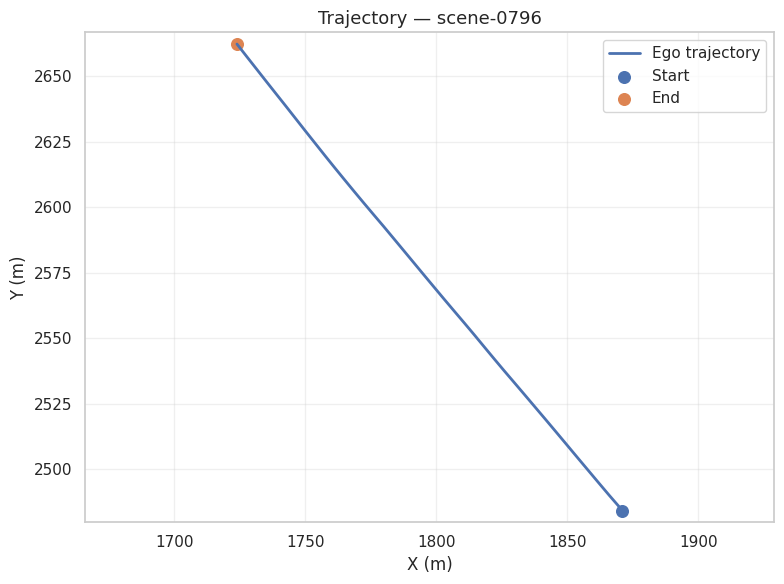

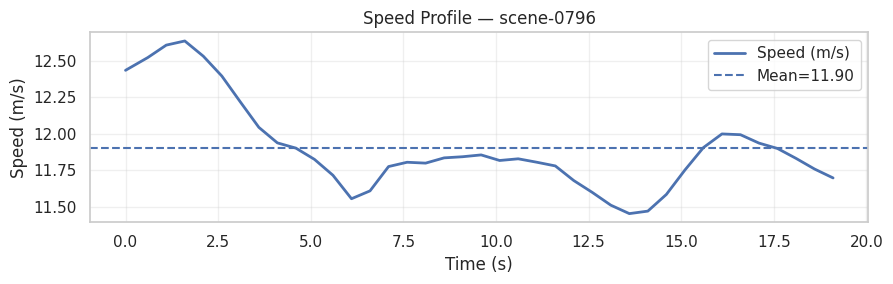

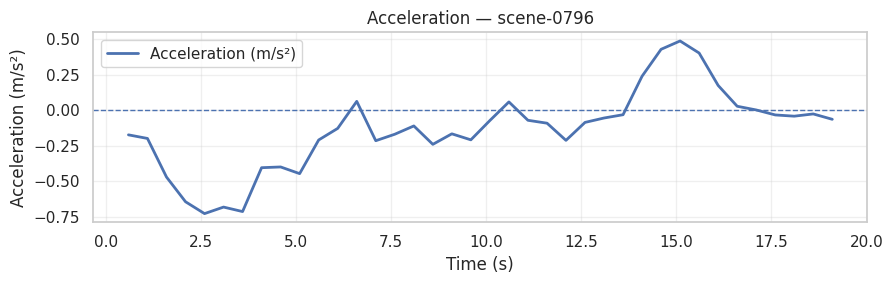

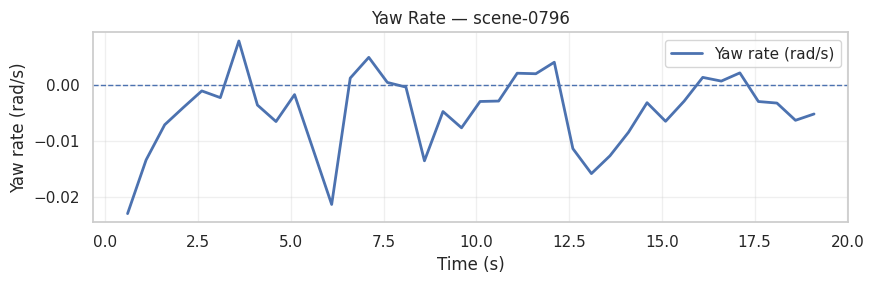

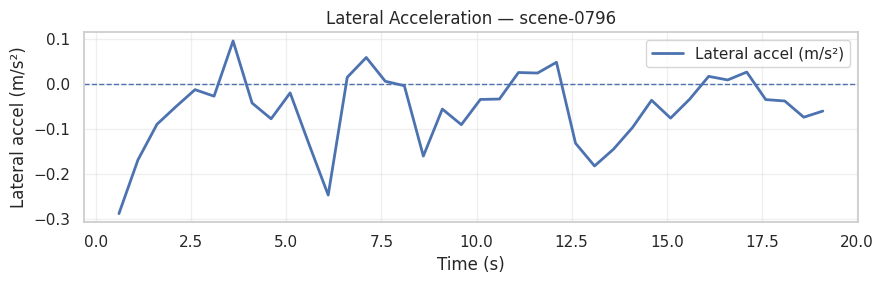

Scene: scene-0061 | CAN-augmented: True
Description: Parked truck, construction, intersection, turn left, following a van
Total heading change (deg): 96.59
Speed: mean=4.85 m/s | max=8.99 m/s
Accel: mean|a|=0.508 m/s^2
Comfort: mean|jerk|=0.257 m/s^3
Stability: max|lat acc|=1.00 m/s^2 | max|yaw rate|=0.23 rad/s


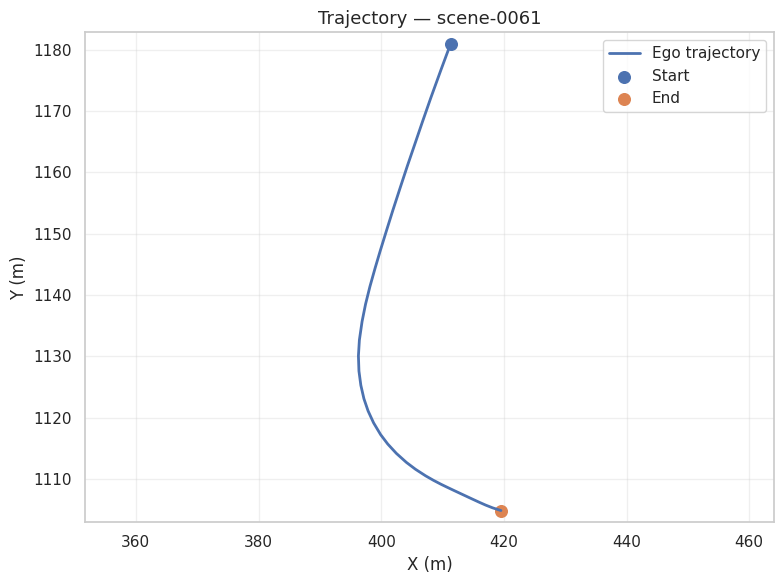

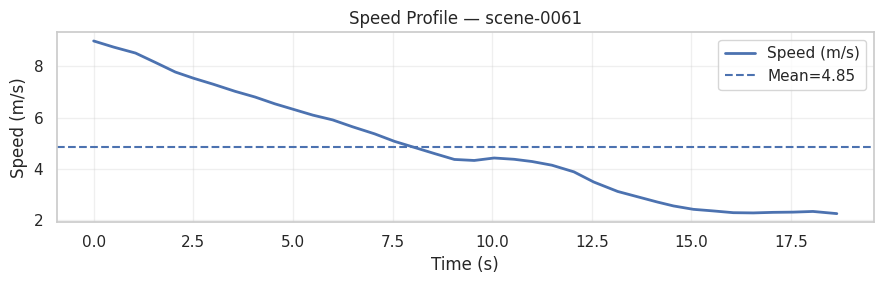

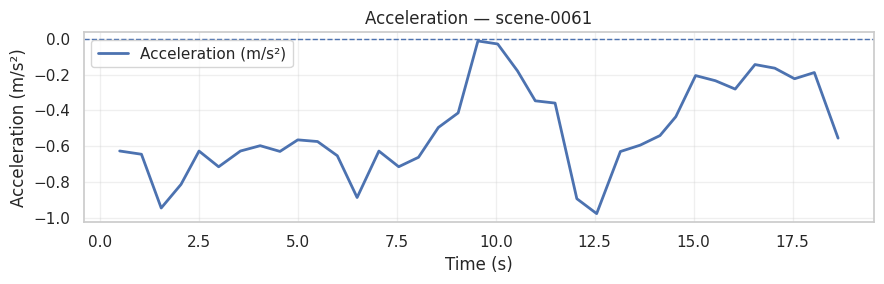

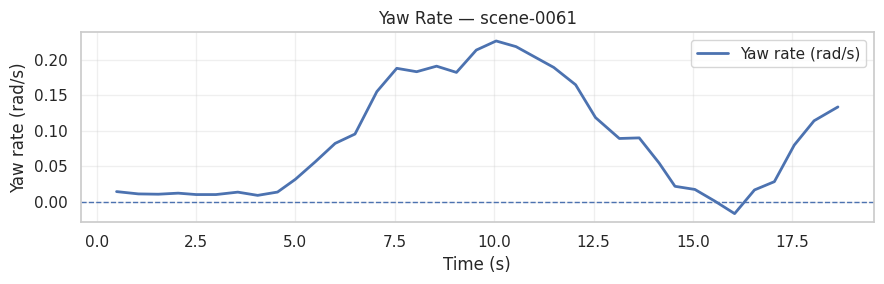

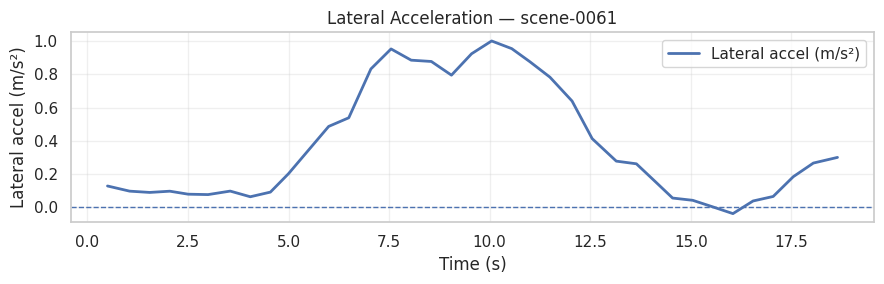

Scene: scene-0916 | CAN-augmented: True
Description: Parking lot, bicycle rack, parked bicycles, bus, many peds, parked scooters, parked motorcycle
Total heading change (deg): 207.12
Speed: mean=4.69 m/s | max=6.00 m/s
Accel: mean|a|=0.476 m/s^2
Comfort: mean|jerk|=0.344 m/s^3
Stability: max|lat acc|=2.07 m/s^2 | max|yaw rate|=0.50 rad/s


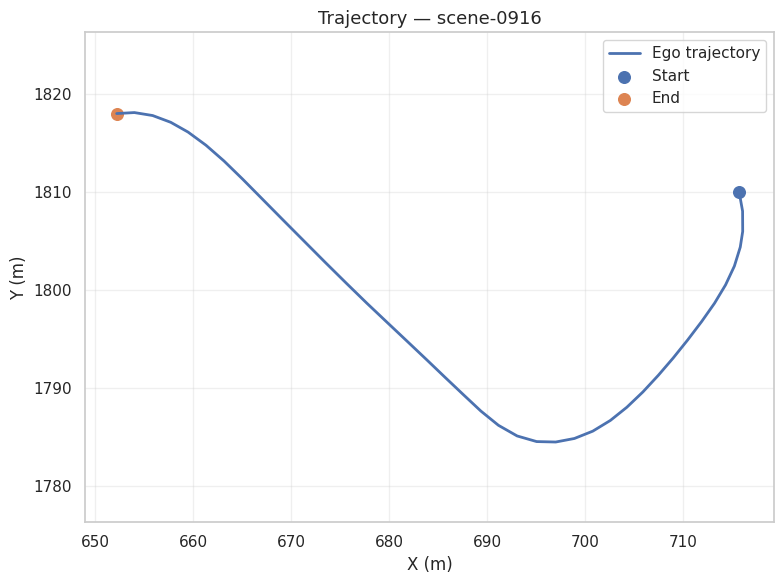

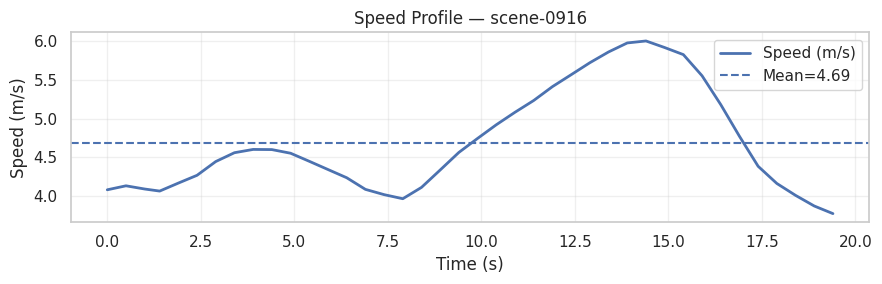

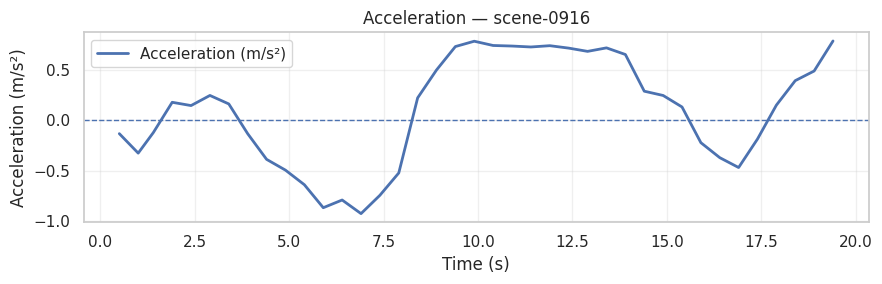

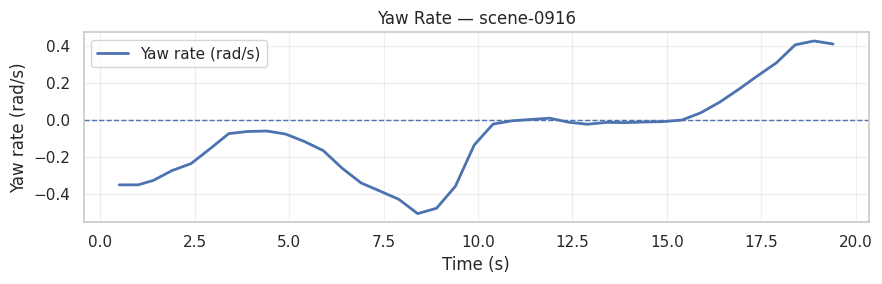

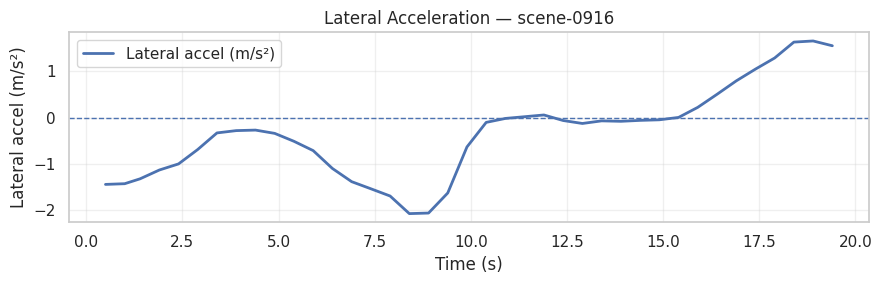


=== Scene Diagnostics Summary (3 scenes) ===


/tmp/ipykernel_17541/1519987535.py:45: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_scene_diag[num_cols] = df_scene_diag[num_cols].apply(pd.to_numeric, errors="ignore")
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,scene,CAN_aug,N,heading_change_deg,avg_speed_mps,max_speed_mps,mean_abs_acc_mps2,mean_abs_jerk_mps3,max_abs_lat_acc_mps2,max_abs_yaw_rate_rps,description
2,scene-0916,True,40,207.119702,4.691453,5.998291,0.475668,0.343978,2.072721,0.503792,"Parking lot, bicycle rack, parked bicycles, bu..."
1,scene-0061,True,38,96.589966,4.849936,8.988726,0.508123,0.256776,0.999724,0.226099,"Parked truck, construction, intersection, turn..."
0,scene-0796,True,39,8.550482,11.900311,12.634212,0.236501,0.213647,0.288513,0.023043,"Scooter, peds on sidewalk, bus, cars, truck, f..."


In [12]:
# Scene diagnostics for 3 scenes and a clean summary DataFrame

import numpy as np
import pandas as pd

scene_list_3 = []
if "df_summary" in globals() and isinstance(df_summary, pd.DataFrame) and "scene" in df_summary.columns:
    # Taking 3 representative scenes from different labels
    if "label" in df_summary.columns:
        scene_list_3 = (
            df_summary.groupby("label")["scene"]
            .first()
            .head(3)
            .tolist()
        )
    else:
        scene_list_3 = df_summary["scene"].head(3).tolist()
elif "traj_db" in globals():
    scene_list_3 = sorted(list(traj_db.keys()))[:3]
else:
    raise RuntimeError("Could not find df_summary or traj_db to select scenes.")

print("Running analysis for scenes:", scene_list_3)

rows = []
for s in scene_list_3:
    m = visualize_scene_analysis(s, show_plots=True)
    rows.append({
        "scene": m["scene"],
        "CAN_aug": m["is_can_augmented"],
        "N": m["N"],
        "heading_change_deg": m["heading_change_deg"],
        "avg_speed_mps": m["avg_speed_mps"],
        "max_speed_mps": m["max_speed_mps"],
        "mean_abs_acc_mps2": m["mean_abs_acc_mps2"],
        "mean_abs_jerk_mps3": m["mean_abs_jerk_mps3"],
        "max_abs_lat_acc_mps2": m["max_abs_lat_acc_mps2"],
        "max_abs_yaw_rate_rps": m["max_abs_yaw_rate_rps"],
        "description": (m.get("description", "")[:90] + "…") if m.get("description", "") else "",
    })

df_scene_diag = pd.DataFrame(rows)

num_cols = [c for c in df_scene_diag.columns if c not in ["scene", "description"]]
df_scene_diag[num_cols] = df_scene_diag[num_cols].apply(pd.to_numeric, errors="ignore")
df_scene_diag = df_scene_diag.sort_values(["heading_change_deg", "avg_speed_mps"], ascending=[False, False])

print("\n=== Scene Diagnostics Summary (3 scenes) ===")
display(df_scene_diag)

## Features, Missing Data Handling, and State/Action Design

### Feature extraction from raw nuScenes
nuScenes raw data is high-dimensional (images, lidar, radar, maps, annotations). For RL efficiency, I extracted a compact ego-motion feature set:
- From **ego pose** / trajectory: position `(x, y)`, heading `psi`
- From **CAN bus** (`pose` stream): speed `v`, longitudinal acceleration `a_x`, yaw rate `r`
This yields CAN-augmented reference states:  
**[x, y, v_can, psi, ax_can, yaw_rate_can]**

This compact representation:
- reduces dimensionality significantly,
- is fast to compute for training,
- directly supports trajectory tracking + comfort.

### Handling missing data, noise, and inconsistencies
Practical issues addressed:
- **Timestamp mismatches / non-increasing timestamps:** filtered (dt > 0 checks).
- **Heading discontinuities:** wrapped to [-pi, pi] using `wrap_to_pi`.
- **CAN stream availability:** stream list is checked per scene and a preferred stream (e.g., `pose`) is selected; if missing, a fallback policy can be used.
- **Noise in derivatives:** yaw-rate and jerk are computed with stabilization and safe guards (e.g., near-zero speed handling).

### State and action representation (continuous + discrete)
**Training observation:**
- `[dx, dy, dv, dpsi, prev_acc_cmd, yaw_rate]`  
where errors are computed relative to the next reference point.  
This keeps the policy transferable across scenes.

**Action space (continuous):**
- `[acceleration_cmd, steering_cmd]` = `[a, delta]`

**Discrete alternative (not used here):**
Actions could be discretized, e.g.:
- acceleration: {brake, coast, accel}
- steering: {left, straight, right}

Continuous control is used because vehicle control is naturally continuous and PPO handles it well.

## Reward Function Design and Penalties

### Reward design goals
The reward is crafted to guide the agent toward:
- **Accurate trajectory tracking** (follow reference path and speed)
- **Comfortable driving** (low jerk, low lateral acceleration)
- **Stable control** (limited yaw-rate oscillations and excessive actuation)
- **Non-trivial progress** (avoid "do nothing" policies)

### Reward terms
The reward combines:
1. **Progress reward:** encourages forward motion
2. **Tracking penalties:** position error, speed error, heading error (optional)
3. **Comfort penalties:** jerk, yaw-rate, lateral acceleration
4. **Control effort penalty:** penalize large acceleration magnitudes
5. **Alive bonus:** small positive constant each step

### Penalties for undesired behaviors
In the trajectory-tracking training environment, explicit collision/lane-departure signals are not available (no interactive traffic/lane constraints). Instead:
- **Comfort penalties** discourage jerky maneuvers.
- In **MetaDrive deployment**, explicit safety signals are monitored:
  - collision flags (crash)
  - off-road flags (out_of_road)

These are reported during rollout as a safety evaluation.

In [13]:
import numpy as np

def compute_reward_can(state, ref_state, jerk, weights, a_cmd: float | None = None):

    x, y, v, psi, ax_can, yaw_rate = map(float, state)

    x_ref = float(ref_state[0])
    y_ref = float(ref_state[1])
    v_ref = float(ref_state[2])
    psi_ref = float(ref_state[3]) if len(ref_state) >= 4 else None

    # Errors
    pos_error = float(np.hypot(x - x_ref, y - y_ref))
    speed_error = float(v - v_ref)

    if psi_ref is not None:
        heading_error = float(wrap_to_pi(psi - psi_ref))
    else:
        heading_error = 0.0

    # Comfort
    lat_acc = float(v * yaw_rate)
    eff = float(a_cmd) if a_cmd is not None else float(ax_can)


    # Robust penalty helpers
    def huber(z, delta):
        z = float(z)
        a = abs(z)
        if a <= delta:
            return 0.5 * (z * z)
        return delta * (a - 0.5 * delta)

    # normalize + clip (to prevent huge gradients)
    pos_scale   = float(weights.get("pos_scale", 10.0))
    speed_scale = float(weights.get("speed_scale", 5.0))

    pos_n   = np.clip(pos_error / pos_scale, 0.0, 3.0)
    dv_n    = np.clip(speed_error / speed_scale, -3.0, 3.0)

    # Using robust penalties
    pos_cost   = huber(pos_n,   delta=1.0)
    speed_cost = huber(dv_n,    delta=1.0)
    head_cost  = huber(heading_error, delta=0.5)

    jerk_cost  = huber(jerk,    delta=2.0)
    lat_cost   = huber(lat_acc, delta=3.0)
    yaw_cost   = huber(yaw_rate,delta=1.0)
    eff_cost   = huber(eff,     delta=2.0)

    # Progress term (gated by tracking)
    v_clip = float(weights.get("v_progress_clip", 30.0))
    progress = float(np.clip(v, 0.0, v_clip))

    # Gate progress if far away (to prevent "go fast while off-path")
    gate_dist = float(weights.get("progress_gate_dist_m", 8.0))
    gate = float(np.exp(- (pos_error / gate_dist) ** 2))  # 1 near path, ->0 far away
    progress_term = gate * progress


    # Reward
    reward = (
        + weights.get("w_progress", 0.2) * progress_term
        - weights.get("w_pos", 2.0)      * pos_cost
        - weights.get("w_speed", 0.5)    * speed_cost
        - weights.get("w_heading", 0.1)  * head_cost
        - weights.get("w_jerk", 0.01)    * jerk_cost
        - weights.get("w_latacc", 0.01)  * lat_cost
        - weights.get("w_yawrate", 0.01) * yaw_cost
        - weights.get("w_acc", 0.001)    * eff_cost
    )

    # Alive bonus: small (or 0) to avoid drift incentives
    reward += float(weights.get("alive_bonus", 0.0))

    return float(reward)

In [14]:
def compute_reward(state, ref_state, jerk, weights):
    return compute_reward_can(state, ref_state, jerk, weights, a_cmd=None)

weights = {
    # Tracking
    "w_pos": 3.0,
    "w_speed": 0.3,
    "w_heading": 0.05,

    # Progress
    "w_progress": 0.15,
    "v_progress_clip": 20.0,
    "progress_gate_dist_m": 8.0,  # To prevent off-path speeding

    # Comfort / stability
    "w_jerk": 0.005,
    "w_latacc": 0.003,
    "w_yawrate": 0.003,

    # Control effort
    "w_acc": 0.0005,

    # Scales
    "pos_scale": 8.0,
    "speed_scale": 4.0,

    # Alive bonus (set to 0 for stability)
    "alive_bonus": 0.0,
}

In [15]:
import numpy as np

class KinematicBicycleModel:

    def __init__(self, wheelbase: float = 2.5, dt: float = 0.1):
        self.L = float(wheelbase)
        self.dt = float(dt)

        # Limits
        self.max_steer = 0.5        # rad
        self.max_steer_rate = 0.4   # rad/s
        self.max_acc = 3.0          # m/s^2
        self.max_speed = 30.0       # m/s

        # Internal steering state after rate limiting
        self.delta = 0.0

    def reset(self):
        self.delta = 0.0

    def step(self, state, action) -> np.ndarray:

        state = np.asarray(state, dtype=np.float32).reshape(-1)
        action = np.asarray(action, dtype=np.float32).reshape(-1)

        if state.shape[0] != 4:
            raise ValueError(f"state must be shape (4,), got {state.shape}")
        if action.shape[0] != 2:
            raise ValueError(f"action must be shape (2,), got {action.shape}")

        x, y, v, psi = float(state[0]), float(state[1]), float(state[2]), float(state[3])
        a_cmd, delta_cmd = float(action[0]), float(action[1])

        # Clip acceleration + steering command
        a = float(np.clip(a_cmd, -self.max_acc, self.max_acc))
        delta_cmd = float(np.clip(delta_cmd, -self.max_steer, self.max_steer))

        # Steering rate limiting
        max_delta_change = self.max_steer_rate * self.dt
        delta_diff = float(np.clip(delta_cmd - self.delta, -max_delta_change, max_delta_change))
        self.delta = float(np.clip(self.delta + delta_diff, -self.max_steer, self.max_steer))

        # State updates
        v_next = float(np.clip(v + a * self.dt, 0.0, self.max_speed))
        psi_dot = (v_next / self.L) * np.tan(self.delta)
        psi_next = float(wrap_to_pi(psi + psi_dot * self.dt))


        x_next = x + v_next * np.cos(psi_next) * self.dt
        y_next = y + v_next * np.sin(psi_next) * self.dt

        return np.array([x_next, y_next, v_next, psi_next], dtype=np.float32)

    @property
    def last_yaw_rate(self) -> float:
        return float(np.nan)

In [16]:
# Quick unit test

import numpy as np

model = KinematicBicycleModel(dt=0.5)
model.reset()

s0 = np.array([0.0, 0.0, 10.0, 0.0], dtype=np.float32)   # x, y, v, psi
u0 = np.array([0.0, 0.1], dtype=np.float32)             # a_cmd, delta_cmd

s1 = model.step(s0, u0)

v_next = float(s1[2])
yaw_rate = (v_next / model.L) * np.tan(model.delta)

print("Initial state:", s0)
print("Action:", u0)
print("Next state:", s1)
print("Applied steering delta (after rate limit):", float(model.delta))
print("Approx yaw_rate (rad/s):", yaw_rate)

Initial state: [ 0.  0. 10.  0.]
Action: [0.  0.1]
Next state: [ 4.899667    0.99662644 10.          0.20066935]
Applied steering delta (after rate limit): 0.10000000149011612
Approx yaw_rate (rad/s): 0.40133869436227093


In [17]:
class MultiSceneTrajectoryTrackingEnv(gym.Env):

    metadata = {"render_modes": []}

    def __init__(
        self,
        traj_db,
        scene_list,
        weights,
        dt: float = 0.1,
        max_episode_steps: int | None = None,
        seed: int = 42,
    ):
        super().__init__()

        self.traj_db = traj_db
        self.scene_list = list(scene_list)
        self.weights = dict(weights)
        self.dt = float(dt)
        self.rng = np.random.default_rng(seed)

        self.model = KinematicBicycleModel(dt=self.dt)

        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(6,), dtype=np.float32
        )

        self.action_space = spaces.Box(
            low=np.array([-3.0, -0.5], dtype=np.float32),
            high=np.array([ 3.0,  0.5], dtype=np.float32),
            dtype=np.float32,
        )

        self.max_episode_steps = max_episode_steps

        # Episode variables
        self.scene_name = None
        self.ref_states = None
        self.ref_times = None
        self.ref_dim = 4
        self.max_steps = None
        self.step_idx = 0
        self.prev_acc = 0.0
        self.state = None

    def _yaw_rate(self, v: float) -> float:
        return float((v / self.model.L) * np.tan(self.model.delta))

    def _get_ref(self, idx: int):

        ref = self.ref_states[idx]
        x_ref = float(ref[0])
        y_ref = float(ref[1])
        v_ref = float(ref[2])
        psi_ref = float(ref[3])

        a_ref = None
        yaw_ref = None
        if self.ref_dim >= 6:
            a_ref = float(ref[4])
            yaw_ref = float(ref[5])

        return x_ref, y_ref, v_ref, psi_ref, a_ref, yaw_ref

    def _make_obs(self, state_xyvpsi, ref_xyvpsi):
        x, y, v, psi = map(float, state_xyvpsi)
        x_ref, y_ref, v_ref, psi_ref = ref_xyvpsi

        dx = x - x_ref
        dy = y - y_ref
        dv = v - v_ref
        dpsi = float(wrap_to_pi(psi - psi_ref))

        yaw_rate = self._yaw_rate(v)

        return np.array(
            [dx, dy, dv, dpsi, float(self.prev_acc), float(yaw_rate)],
            dtype=np.float32
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.scene_name = str(self.rng.choice(self.scene_list))
        self.ref_states, self.ref_times = self.traj_db[self.scene_name]
        self.ref_states = np.asarray(self.ref_states, dtype=np.float32)

        if self.ref_states.ndim != 2 or self.ref_states.shape[1] not in (4, 6):
            raise ValueError(
                f"ref_states must be (N,4) or (N,6). Got {self.ref_states.shape} for scene {self.scene_name}"
            )

        self.ref_dim = int(self.ref_states.shape[1])

        # Episode length
        self.max_steps = int(len(self.ref_states) - 1)
        if self.max_episode_steps is not None:
            self.max_steps = min(self.max_steps, int(self.max_episode_steps))

        # Resetting dynamics
        self.step_idx = 0
        self.prev_acc = 0.0
        self.model.reset()


        x0, y0, v0, psi0 = map(float, self.ref_states[0, :4])
        self.state = np.array([x0, y0, v0, psi0], dtype=np.float32)

        x_ref, y_ref, v_ref, psi_ref, _, _ = self._get_ref(0)
        obs = self._make_obs(self.state, (x_ref, y_ref, v_ref, psi_ref))

        info = {"scene_name": self.scene_name, "ref_dim": self.ref_dim}
        return obs, info

    def step(self, action):
        action = np.asarray(action, dtype=np.float32).reshape(-1)
        if action.shape[0] != 2:
            raise ValueError(f"Action must be shape (2,), got {action.shape}")

        a, delta = float(action[0]), float(action[1])


        if self.step_idx >= self.max_steps:
            x_ref, y_ref, v_ref, psi_ref, _, _ = self._get_ref(self.step_idx)
            obs = self._make_obs(self.state, (x_ref, y_ref, v_ref, psi_ref))
            info = {"scene_name": self.scene_name, "ref_dim": self.ref_dim}
            return obs, 0.0, False, True, info

        # Jerk (comfort)
        jerk = float((a - self.prev_acc) / self.dt)
        self.prev_acc = a

        next_state = self.model.step(self.state, np.array([a, delta], dtype=np.float32))
        x, y, v, psi = map(float, next_state)

        yaw_rate = self._yaw_rate(v)
        lat_acc = float(v * yaw_rate)

        extended_state = np.array([x, y, v, psi, a, yaw_rate], dtype=np.float32)

        # Reference for next step
        nxt = min(self.step_idx + 1, len(self.ref_states) - 1)
        x_ref, y_ref, v_ref, psi_ref, a_ref, yaw_ref = self._get_ref(nxt)

        # Base reward
        reward = compute_reward(
            extended_state,
            [x_ref, y_ref, v_ref, psi_ref],
            jerk,
            self.weights,
        )


        if (a_ref is not None) and ("w_acc_ref" in self.weights):
            reward -= float(self.weights.get("w_acc_ref", 0.0)) * float((a - a_ref) ** 2)

        if (yaw_ref is not None) and ("w_yaw_ref" in self.weights):
            reward -= float(self.weights.get("w_yaw_ref", 0.0)) * float((yaw_rate - yaw_ref) ** 2)


        self.state = next_state
        self.step_idx += 1

        terminated = False
        truncated = self.step_idx >= self.max_steps

        obs = self._make_obs(self.state, (x_ref, y_ref, v_ref, psi_ref))

        info = {
            "scene_name": self.scene_name,
            "ref_dim": self.ref_dim,
            "pos_error": float(np.hypot(x - x_ref, y - y_ref)),
            "speed_error": float(v - v_ref),
            "heading_error": float(wrap_to_pi(psi - psi_ref)),
            "jerk": float(jerk),
            "yaw_rate": float(yaw_rate),
            "lat_acc": float(lat_acc),
        }


        if a_ref is not None:
            info["acc_ref_can"] = float(a_ref)
        if yaw_ref is not None:
            info["yaw_ref_can"] = float(yaw_ref)

        return obs, float(reward), terminated, truncated, info

## Train/Test Split and Evaluation Plan

- I used an **70/30 split** across scenes (train scenes vs held-out test scenes).
- Purpose:
  - To train on multiple driving contexts (multi-scene generalization)
  - To evaluate whether the learned policy transfers to unseen scenes

- As nuScenes mini has only 10 scenes, results are reported:
  - per-scene table,
  - mean and standard deviation,
  - training curves (Monitor + EvalCallback).

In [18]:
# Train / Test Split

all_scenes = sorted(list(traj_db.keys()))

# 70/30 split
split_idx = int(0.7 * len(all_scenes))

train_scenes = all_scenes[:split_idx]
test_scenes  = all_scenes[split_idx:]

print("Total scenes:", len(all_scenes))
print("Train scenes:", len(train_scenes))
print("Test scenes :", len(test_scenes))
print("Example train scene:", train_scenes[0] if train_scenes else None)
print("Example test scene :", test_scenes[0] if test_scenes else None)

Total scenes: 10
Train scenes: 7
Test scenes : 3
Example train scene: scene-0061
Example test scene : scene-1077


In [19]:
# Smoke test (single-env) for MultiSceneTrajectoryTrackingEnv

train_env = Monitor(
    MultiSceneTrajectoryTrackingEnv(
        traj_db=traj_db,
        scene_list=train_scenes,
        weights=weights,
        dt=0.5,
        seed=42
    )
)

obs, info = train_env.reset()
print("Reset OK:", info, "| Obs shape:", obs.shape)

action = train_env.action_space.sample()
obs, r, term, trunc, info = train_env.step(action)

print("Step OK: r=", float(r), "| scene=", info.get("scene_name"))
print("Terminated:", term, "| Truncated:", trunc)
print("Info keys:", list(info.keys()))

# Quick sanity on reference format
base_env = train_env.unwrapped
print("ref_states shape:", np.asarray(base_env.ref_states).shape, "| ref_dim:", getattr(base_env, "ref_dim", None))

Reset OK: {'scene_name': 'scene-0061', 'ref_dim': 6} | Obs shape: (6,)
Step OK: r= 0.9814440908178493 | scene= scene-0061
Terminated: False | Truncated: False
Info keys: ['scene_name', 'ref_dim', 'pos_error', 'speed_error', 'heading_error', 'jerk', 'yaw_rate', 'lat_acc', 'acc_ref_can', 'yaw_ref_can']
ref_states shape: (38, 6) | ref_dim: 6


In [20]:
# Open-loop Baseline (zero action)

import numpy as np
import pandas as pd

def run_zero_action_baseline(scene_list, dt=0.5, seed=0):
    rows = []

    for scene_name in list(scene_list):

        env = MultiSceneTrajectoryTrackingEnv(
            traj_db=traj_db,
            scene_list=[scene_name],
            weights=weights,
            dt=dt,
            seed=seed
        )

        obs, info = env.reset(seed=seed)
        total_reward = 0.0
        pos_errors = []
        n_steps = 0

        done = False
        while not done:
            action = np.array([0.0, 0.0], dtype=np.float32)
            obs, reward, terminated, truncated, info = env.step(action)

            total_reward += float(reward)
            pos_errors.append(float(info.get("pos_error", np.nan)))
            n_steps += 1
            done = bool(terminated) or bool(truncated)

        rows.append({
            "scene": scene_name,
            "episode_return": float(total_reward),
            "mean_pos_error_m": float(np.nanmean(pos_errors)),
            "max_pos_error_m": float(np.nanmax(pos_errors)),
            "steps": int(n_steps),
        })

    df = pd.DataFrame(rows).sort_values("scene").reset_index(drop=True)
    return df


baseline_df = run_zero_action_baseline(test_scenes, dt=0.5, seed=123)
baseline_df

,scene,episode_return,mean_pos_error_m,max_pos_error_m,steps
0,scene-1077,-252.408627,73.103785,169.343529,39
1,scene-1094,-193.296196,35.572501,111.298176,38
2,scene-1100,-0.707769,0.468028,1.035664,38


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [21]:
# Baseline summary (zero action)

import numpy as np

print("Baseline summary (zero action):")
print(f"Scenes evaluated: {len(baseline_df)}")

mean_return = float(baseline_df["episode_return"].mean())
std_return  = float(baseline_df["episode_return"].std(ddof=1)) if len(baseline_df) > 1 else 0.0

mean_err = float(baseline_df["mean_pos_error_m"].mean())
std_err  = float(baseline_df["mean_pos_error_m"].std(ddof=1)) if len(baseline_df) > 1 else 0.0

mean_steps = float(baseline_df["steps"].mean())
std_steps  = float(baseline_df["steps"].std(ddof=1)) if len(baseline_df) > 1 else 0.0

print(f"Mean return:            {mean_return:.3f}")
print(f"Std return:             {std_return:.3f}")
print(f"Mean position error (m): {mean_err:.3f}")
print(f"Std position error (m):  {std_err:.3f}")
print(f"Mean steps:             {mean_steps:.1f}")
print(f"Std steps:              {std_steps:.1f}")

Baseline summary (zero action):
Scenes evaluated: 3
Mean return:            -148.804
Std return:             131.617
Mean position error (m): 36.381
Std position error (m):  36.325
Mean steps:             38.3
Std steps:              0.6


In [22]:
class PurePursuitController:

    def __init__(
        self,
        wheelbase: float = 2.5,
        lookahead_distance: float = 5.0,
        max_steer: float = 0.5,
        max_acc: float = 3.0,
        k_speed: float = 0.5,
        min_lookahead: float = 2.0,
        max_lookahead: float = 15.0,
    ):
        self.L = float(wheelbase)
        self.Ld = float(lookahead_distance)
        self.max_steer = float(max_steer)
        self.max_acc = float(max_acc)
        self.k_speed = float(k_speed)
        self.min_lookahead = float(min_lookahead)
        self.max_lookahead = float(max_lookahead)
        self.ref_states: np.ndarray | None = None

    def set_reference(self, reference_states: np.ndarray):
        rs = np.asarray(reference_states, dtype=np.float32)
        if rs.ndim != 2 or rs.shape[1] < 3:
            raise ValueError(f"reference_states must be (N,>=3) [x,y,v,...]. Got {rs.shape}")
        self.ref_states = rs

    def get_action(self, current_state: np.ndarray) -> np.ndarray:
        if self.ref_states is None or len(self.ref_states) < 2:
            return np.array([0.0, 0.0], dtype=np.float32)

        cs = np.asarray(current_state, dtype=np.float32).reshape(-1)
        x, y, v, psi = map(float, cs[:4])

        ref_xy = self.ref_states[:, :2]
        dxy = ref_xy - np.array([x, y], dtype=np.float32)
        dists = np.linalg.norm(dxy, axis=1)
        nearest_idx = int(np.argmin(dists))

        # Speed-adaptive lookahead
        Ld = float(np.clip(self.Ld + 0.3 * v, self.min_lookahead, self.max_lookahead))

        # Target index
        target_idx = nearest_idx
        while target_idx < len(ref_xy) - 1 and dists[target_idx] < Ld:
            target_idx += 1

        x_ref, y_ref = map(float, ref_xy[target_idx])

        # Heading error to target
        target_angle = float(np.arctan2(y_ref - y, x_ref - x))
        alpha = float(wrap_to_pi(target_angle - psi))

        # Pure pursuit steering (command)
        delta = float(np.arctan2(2.0 * self.L * np.sin(alpha), Ld))
        delta = float(np.clip(delta, -self.max_steer, self.max_steer))

        # Speed tracking (P control)
        v_ref = float(self.ref_states[target_idx, 2])
        accel = self.k_speed * (v_ref - v)
        accel = float(np.clip(accel, -self.max_acc, self.max_acc))

        return np.array([accel, delta], dtype=np.float32)

In [23]:
# Pure Pursuit baseline

def run_pure_pursuit_baseline(scene_list, lookahead=5.0, seed=123, dt=0.5):
    rows = []

    for scene_name in list(scene_list):

        env = MultiSceneTrajectoryTrackingEnv(
            traj_db=traj_db,
            scene_list=[scene_name],
            weights=weights,
            dt=dt,
            seed=seed
        )

        ctrl = PurePursuitController(lookahead_distance=lookahead)

        obs, info = env.reset(seed=seed)
        ctrl.set_reference(env.ref_states)

        total_reward = 0.0
        pos_errors = []
        steps = 0

        done = False
        while not done:
            action = ctrl.get_action(env.state)  # uses true state [x,y,v,psi]
            obs, reward, terminated, truncated, info = env.step(action)

            total_reward += float(reward)
            pos_errors.append(float(info.get("pos_error", np.nan)))
            steps += 1

            done = bool(terminated or truncated)

        rows.append({
            "scene": scene_name,
            "episode_return": float(total_reward),
            "mean_pos_error_m": float(np.nanmean(pos_errors)),
            "max_pos_error_m": float(np.nanmax(pos_errors)),
            "steps": int(steps),
        })

    df = pd.DataFrame(rows).sort_values("scene").reset_index(drop=True)
    return df


pp_df = run_pure_pursuit_baseline(test_scenes, lookahead=5.0, seed=123, dt=0.5)
pp_df

,scene,episode_return,mean_pos_error_m,max_pos_error_m,steps
0,scene-1077,6.808337,5.168084,10.244103,39
1,scene-1094,-23.265162,5.986560,8.953410,38
2,scene-1100,-0.707769,0.468028,1.035664,38


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [24]:
# Baseline summary (Pure Pursuit)

import numpy as np

print("Baseline summary (Pure Pursuit):")
print(f"Scenes evaluated: {len(pp_df)}")

mean_return = float(pp_df["episode_return"].mean())
std_return  = float(pp_df["episode_return"].std(ddof=1)) if len(pp_df) > 1 else 0.0

mean_err = float(pp_df["mean_pos_error_m"].mean())
std_err  = float(pp_df["mean_pos_error_m"].std(ddof=1)) if len(pp_df) > 1 else 0.0

mean_steps = float(pp_df["steps"].mean())
std_steps  = float(pp_df["steps"].std(ddof=1)) if len(pp_df) > 1 else 0.0

print(f"Mean return:             {mean_return:.3f}")
print(f"Std return:              {std_return:.3f}")
print(f"Mean position error (m): {mean_err:.3f}")
print(f"Std position error (m):  {std_err:.3f}")
print(f"Mean steps:              {mean_steps:.1f}")
print(f"Std steps:               {std_steps:.1f}")

Baseline summary (Pure Pursuit):
Scenes evaluated: 3
Mean return:             -5.722
Std return:              15.651
Mean position error (m): 3.874
Std position error (m):  2.978
Mean steps:              38.3
Std steps:               0.6


Scene: scene-1077
Total reward (Pure Pursuit): 6.81
Mean position error (m): 5.168
Max position error  (m): 10.244


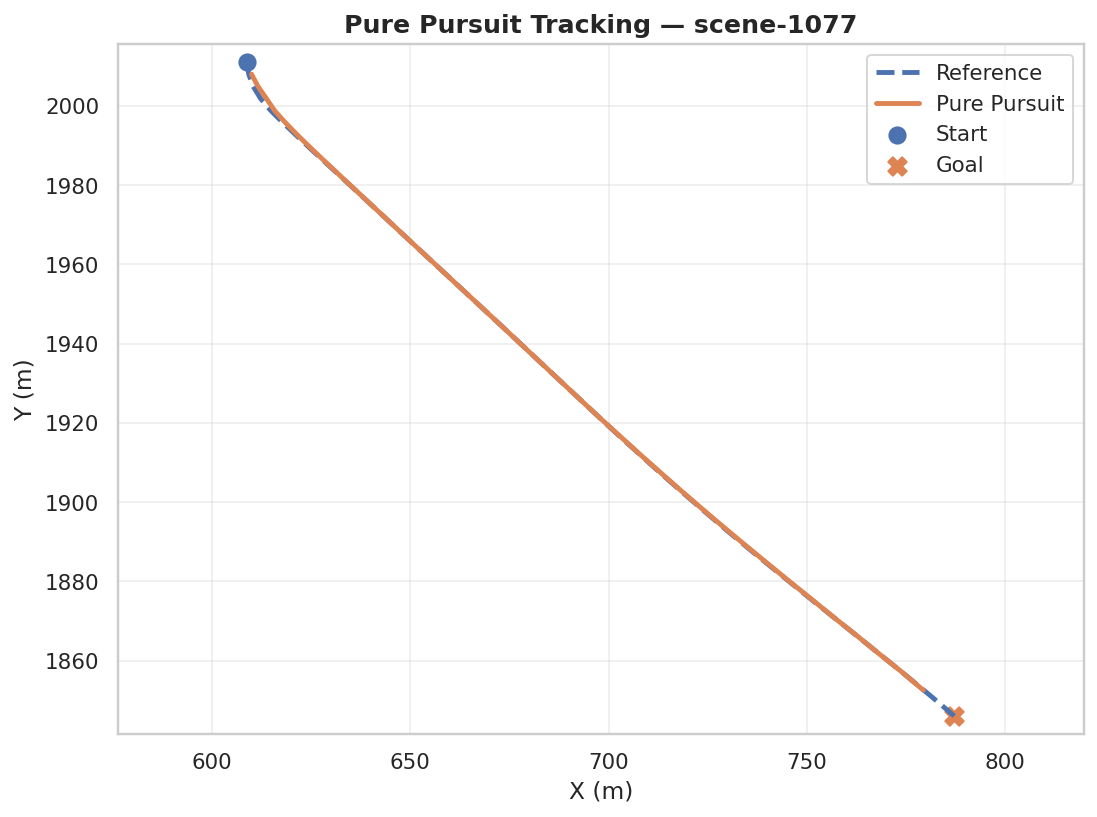

In [25]:
# Pure Pursuit rollout and plot (single fixed scene)

def pure_pursuit_rollout_one_scene(
    scene_name: str,
    lookahead: float = 5.0,
    seed: int = 0,
    dt: float = 0.5,
    save_fig: bool = True,
):

    env = MultiSceneTrajectoryTrackingEnv(
        traj_db=traj_db,
        scene_list=[scene_name],
        weights=weights,
        dt=dt,
        seed=seed
    )
    ctrl = PurePursuitController(lookahead_distance=lookahead)

    obs, info = env.reset(seed=seed)
    ctrl.set_reference(env.ref_states)

    ref_states = np.asarray(env.ref_states, dtype=np.float32)
    ref_xy = ref_states[:, :2]

    traj_states = []
    pos_errors = []
    total_reward = 0.0

    done = False
    while not done:
        action = ctrl.get_action(env.state)  # use true state [x,y,v,psi]
        obs, reward, terminated, truncated, info = env.step(action)

        traj_states.append(env.state.copy())
        total_reward += float(reward)
        pos_errors.append(float(info.get("pos_error", np.nan)))

        done = bool(terminated or truncated)

    traj_states = np.asarray(traj_states, dtype=np.float32)
    traj_xy = traj_states[:, :2]

    print(f"Scene: {scene_name}")
    print(f"Total reward (Pure Pursuit): {total_reward:.2f}")
    print(f"Mean position error (m): {np.nanmean(pos_errors):.3f}")
    print(f"Max position error  (m): {np.nanmax(pos_errors):.3f}")

    plt.figure(figsize=(8, 6), dpi=140)
    plt.plot(ref_xy[:, 0], ref_xy[:, 1], "--", linewidth=2.5, label="Reference")
    plt.plot(traj_xy[:, 0], traj_xy[:, 1], "-",  linewidth=2.5, label="Pure Pursuit")
    plt.scatter(ref_xy[0, 0],  ref_xy[0, 1],  s=70, label="Start")
    plt.scatter(ref_xy[-1, 0], ref_xy[-1, 1], s=90, marker="X", label="Goal")
    plt.title(f"Pure Pursuit Tracking — {scene_name}", fontsize=13, weight="bold")
    plt.xlabel("X (m)")
    plt.ylabel("Y (m)")
    plt.axis("equal")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    if save_fig:
        plt.savefig(f"pure_pursuit_{scene_name}.png", dpi=180, bbox_inches="tight")

    plt.show()

    return traj_states, ref_states


# Plot one test scene
scene_to_plot = test_scenes[0]
pp_states_one, ref_states_one = pure_pursuit_rollout_one_scene(
    scene_to_plot, lookahead=5.0, seed=0, dt=0.5, save_fig=True
)

In [26]:
# Training Envs and PPO (Multi-scene)

import os
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.logger import configure

DT = 0.5
TOTAL_TIMESTEPS = 700000
log_dir = "./logs_multiscene_dt05_fixed"
os.makedirs(log_dir, exist_ok=True)

# Vectorization
N_ENVS = 8

def make_env(scene_list, seed):
    def _init():
        env = MultiSceneTrajectoryTrackingEnv(
            traj_db=traj_db,
            scene_list=scene_list,
            weights=weights,
            dt=DT,
            seed=seed
        )
        return Monitor(env)
    return _init

# Vectorized training envs
train_env = DummyVecEnv([make_env(train_scenes, 1000 + i) for i in range(N_ENVS)])

# Single eval env
eval_env = DummyVecEnv([make_env(test_scenes, 2000)])

# Normalizing obs + reward during training
train_env = VecNormalize(train_env, norm_obs=True, norm_reward=True, clip_obs=10.0)

# Eval env:
eval_env = VecNormalize(eval_env, norm_obs=True, norm_reward=False, clip_obs=10.0)
eval_env.obs_rms = train_env.obs_rms
eval_env.ret_rms = train_env.ret_rms
eval_env.training = False
eval_env.norm_reward = False

# Logger (stdout + csv + tensorboard)
logger = configure(log_dir, ["stdout", "csv", "tensorboard"])

# PPO model
model = PPO(
    "MlpPolicy",
    train_env,
    verbose=1,
    learning_rate=2e-4,
    n_steps=2048,
    batch_size=128,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.001,
    vf_coef=0.5,
    max_grad_norm=0.5,
    device="auto",
    seed=42
)
model.set_logger(logger)

# EvalCallback
eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=log_dir,
    log_path=log_dir,
    eval_freq=5000,
    n_eval_episodes=10,
    deterministic=True,
    render=False
)

# Training
model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=eval_callback)

# Save final model + VecNormalize stats
model.save(os.path.join(log_dir, "ppo_multiscene_final"))
train_env.save(os.path.join(log_dir, "vecnormalize.pkl"))

print("Saved model:", os.path.join(log_dir, "ppo_multiscene_final.zip"))
print("Saved VecNormalize stats:", os.path.join(log_dir, "vecnormalize.pkl"))

Logging to ./logs_multiscene_dt05_fixed
Using cpu device


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 38.4     |
|    ep_rew_mean     | -221     |
| time/              |          |
|    fps             | 1687     |
|    iterations      | 1        |
|    time_elapsed    | 9        |
|    total_timesteps | 16384    |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 38.4         |
|    ep_rew_mean          | -212         |
| time/                   |              |
|    fps                  | 1764         |
|    iterations           | 2            |
|    time_elapsed         | 18           |
|    total_timesteps      | 32768        |
| train/                  |              |
|    approx_kl            | 0.0057068863 |
|    clip_fraction        | 0.0435       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.83        |
|    explained_variance   | 0.139        |
|    learning_r

log_dir: ./logs_multiscene_dt05_fixed
Monitor file: None
No monitor.csv found. (Training may not have saved Monitor logs.)
Eval file: ./logs_multiscene_dt05_fixed/evaluations.npz | Exists: True


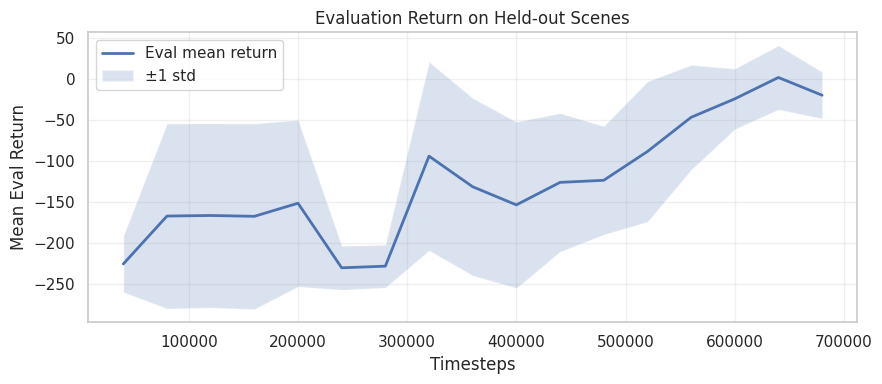

Eval points: 17
Last 5 eval mean returns: [-88.4812019, -46.7016416, -24.1431264, 1.9817740999999995, -19.689937500000003]


In [27]:
# Training plots and curves (PPO multi-scene)
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _find_latest_monitor_csv(root_dir: str):
    candidates = sorted(glob.glob(os.path.join(root_dir, "**", "monitor.csv"), recursive=True))
    if not candidates:
        candidates = sorted(list(set(glob.glob("./**/monitor.csv", recursive=True))))
    if not candidates:
        return None

    candidates = sorted(candidates, key=lambda p: os.path.getmtime(p))
    return candidates[-1]

def _read_monitor_csv(path: str):

    with open(path, "r") as f:
        lines = f.readlines()
    skip = 0
    for i, line in enumerate(lines):
        if line.startswith("#"):
            skip += 1
        else:
            break
    df = pd.read_csv(path, skiprows=skip)
    return df

# Training returns from Monitor
if "log_dir" not in globals():
    raise NameError("log_dir is not defined. Please set log_dir (same as training) before running this cell.")

monitor_path = _find_latest_monitor_csv(log_dir)

print("log_dir:", log_dir)
print("Monitor file:", monitor_path)

if monitor_path is None:
    print("No monitor.csv found. (Training may not have saved Monitor logs.)")
else:
    df = _read_monitor_csv(monitor_path).copy()

    # Typical columns: r, l, t (return, length, time)
    if "r" not in df.columns:
        raise ValueError(f"monitor.csv does not contain column 'r'. Columns found: {df.columns.tolist()}")

    df["episode"] = np.arange(len(df))
    # smooth
    window = 20
    df["r_smooth"] = pd.to_numeric(df["r"], errors="coerce").rolling(window=window, min_periods=1).mean()

    plt.figure(figsize=(9, 4))
    plt.plot(df["episode"], df["r"], alpha=0.35, label="Episode return (raw)")
    plt.plot(df["episode"], df["r_smooth"], linewidth=2.0, label=f"Rolling mean ({window} eps)")
    plt.xlabel("Episode")
    plt.ylabel("Episode Return")
    plt.title("Training Episode Return (PPO, Multi-Scene)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # quick stats
    print(f"Episodes logged: {len(df)}")
    print(f"Last episode return: {float(df['r'].iloc[-1]):.3f}")

# Eval curve from EvalCallback (evaluations.npz)
eval_path = os.path.join(log_dir, "evaluations.npz")
print("Eval file:", eval_path, "| Exists:", os.path.exists(eval_path))

if not os.path.exists(eval_path):
    print("No evaluations.npz found yet. (EvalCallback may not have run/saved.)")
else:
    data = np.load(eval_path)

    timesteps = data["timesteps"]              # shape (n_eval,)
    results = data["results"]                  # shape (n_eval, n_eval_episodes)
    mean_rewards = results.mean(axis=1)
    std_rewards = results.std(axis=1)

    plt.figure(figsize=(9, 4))
    plt.plot(timesteps, mean_rewards, linewidth=2.0, label="Eval mean return")
    plt.fill_between(
        timesteps,
        mean_rewards - std_rewards,
        mean_rewards + std_rewards,
        alpha=0.2,
        label="±1 std"
    )
    plt.xlabel("Timesteps")
    plt.ylabel("Mean Eval Return")
    plt.title("Evaluation Return on Held-out Scenes")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("Eval points:", len(timesteps))
    print("Last 5 eval mean returns:", [float(x) for x in mean_rewards[-5:]])

In [28]:
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.monitor import Monitor
import numpy as np
import pandas as pd
import os

def evaluate_ppo_per_scene(
    model,
    scene_list,
    vecnorm_path,
    dt=0.5,
    seed=0,
    deterministic=True
):
    rows = []

    for scene_name in scene_list:

        def _make_env(sn=scene_name):
            env = MultiSceneTrajectoryTrackingEnv(
                traj_db=traj_db,
                scene_list=[sn],
                weights=weights,
                dt=dt,
                seed=seed
            )
            return Monitor(env)

        venv = DummyVecEnv([_make_env])

        # Loading VecNormalize stats
        venv = VecNormalize.load(vecnorm_path, venv)
        venv.training = False
        venv.norm_reward = False


        obs = venv.reset()

        total_r = 0.0
        pos_errs = []
        steps = 0

        while True:
            action, _ = model.predict(obs, deterministic=deterministic)
            obs, rewards, dones, infos = venv.step(action)

            info = infos[0]
            total_r += float(rewards[0])
            if "pos_error" in info:
                pos_errs.append(float(info["pos_error"]))
            steps += 1

            if bool(dones[0]):
                break

        venv.close()

        # Robust stats even if pos_errs empty
        mean_err = float(np.mean(pos_errs)) if len(pos_errs) else np.nan
        max_err  = float(np.max(pos_errs))  if len(pos_errs) else np.nan

        rows.append({
            "scene": scene_name,
            "steps": int(steps),
            "episode_return": float(total_r),
            "mean_pos_error_m": mean_err,
            "max_pos_error_m": max_err,
        })

    df = pd.DataFrame(rows)

    print("=== PPO (VecNormalize) Test Summary ===")
    print(f"Scenes evaluated: {len(df)}")
    print("Mean return:", df["episode_return"].mean())
    print("Mean pos error (m):", df["mean_pos_error_m"].mean())
    print("Median pos error (m):", df["mean_pos_error_m"].median())
    print("Std pos error (m):", df["mean_pos_error_m"].std())
    print("======================================")

    return df


ppo_df = evaluate_ppo_per_scene(
    model=model,
    scene_list=test_scenes,
    vecnorm_path=os.path.join(log_dir, "vecnormalize.pkl"),
    dt=DT,
    seed=123,
    deterministic=True
)

ppo_df

=== PPO (VecNormalize) Test Summary ===
Scenes evaluated: 3
Mean return: -2.1348783332083863
Mean pos error (m): 3.491583475948463
Median pos error (m): 3.2706851014640033
Std pos error (m): 2.9385377220128035


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,scene,steps,episode_return,mean_pos_error_m,max_pos_error_m
0,scene-1077,39,-15.189573,6.534337,18.272487
1,scene-1094,38,8.987456,3.270685,8.007896
2,scene-1100,38,-0.202518,0.669729,1.985093


In [29]:
# Comparison summary table (Zero / Pure Pursuit / PPO)
import numpy as np
import pandas as pd

def _safe_mean(df, col):
    if df is None or col not in df.columns or len(df) == 0:
        return np.nan
    return float(pd.to_numeric(df[col], errors="coerce").mean())

def _safe_std(df, col):
    if df is None or col not in df.columns or len(df) == 0:
        return np.nan
    return float(pd.to_numeric(df[col], errors="coerce").std())

def _safe_median(df, col):
    if df is None or col not in df.columns or len(df) == 0:
        return np.nan
    return float(pd.to_numeric(df[col], errors="coerce").median())

def _safe_max(df, col):
    if df is None or col not in df.columns or len(df) == 0:
        return np.nan
    return float(pd.to_numeric(df[col], errors="coerce").max())

summary = pd.DataFrame([
    {
        "Method": "Zero Action",
        "Scenes": int(len(baseline_df)) if baseline_df is not None else 0,
        "Mean Return": _safe_mean(baseline_df, "episode_return"),
        "Std Return":  _safe_std(baseline_df, "episode_return"),
        "Mean Pos Error (m)": _safe_mean(baseline_df, "mean_pos_error_m"),
        "Median Pos Error (m)": _safe_median(baseline_df, "mean_pos_error_m"),
        "Max Pos Error (m)": _safe_max(baseline_df, "max_pos_error_m"),
    },
    {
        "Method": "Pure Pursuit",
        "Scenes": int(len(pp_df)) if pp_df is not None else 0,
        "Mean Return": _safe_mean(pp_df, "episode_return"),
        "Std Return":  _safe_std(pp_df, "episode_return"),
        "Mean Pos Error (m)": _safe_mean(pp_df, "mean_pos_error_m"),
        "Median Pos Error (m)": _safe_median(pp_df, "mean_pos_error_m"),
        "Max Pos Error (m)": _safe_max(pp_df, "max_pos_error_m"),
    },
    {
        "Method": "PPO (VecNorm)",
        "Scenes": int(len(ppo_df)) if ppo_df is not None else 0,
        "Mean Return": _safe_mean(ppo_df, "episode_return"),
        "Std Return":  _safe_std(ppo_df, "episode_return"),
        "Mean Pos Error (m)": _safe_mean(ppo_df, "mean_pos_error_m"),
        "Median Pos Error (m)": _safe_median(ppo_df, "mean_pos_error_m"),
        "Max Pos Error (m)": _safe_max(ppo_df, "max_pos_error_m"),
    },
])


summary_display = summary.copy()
for c in summary_display.columns:
    if c not in ["Method", "Scenes"]:
        summary_display[c] = summary_display[c].map(lambda x: np.nan if pd.isna(x) else round(float(x), 4))

summary_display

,Method,Scenes,Mean Return,Std Return,Mean Pos Error (m),Median Pos Error (m),Max Pos Error (m)
0,Zero Action,3,-148.8042,131.6168,36.3814,35.5725,169.3435
1,Pure Pursuit,3,-5.7215,15.6511,3.8742,5.1681,10.2441
2,PPO (VecNorm),3,-2.1349,12.2038,3.4916,3.2707,18.2725


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Interpretation (Baseline vs PPO)

- **Tracking accuracy:** PPO is competitive with Pure Pursuit on held-out scenes (lower mean and median position error).
- **Worst-case robustness:** PPO shows a higher *max* position error than Pure Pursuit, indicating occasional deviations (tail risk) on limited v1.0-mini data.
- **Reward vs metrics:** Episode return is included for completeness, but **tracking error (meters)** is the primary performance metric because the reward aggregates multiple penalties (comfort, stability, effort).

## Trajectory Planning Demonstration

This section demonstrates that the trained policy can:
- follow a reference trajectory on a driving scene map,
- produce stable rollouts step-by-step,
- visualize trajectory tracking (Reference vs Pure Pursuit vs PPO).

Deliverables in this section:
- Per-scene tracking error table
- Overlay plot: Reference vs Pure Pursuit vs PPO
- Side-by-side tracking GIFs


===== Evaluating scene-1077 =====
Pure Pursuit Mean Error: 1.507 m | Max: 3.061 m
RL (PPO) Mean Error:     3.832 m | Max: 15.258 m


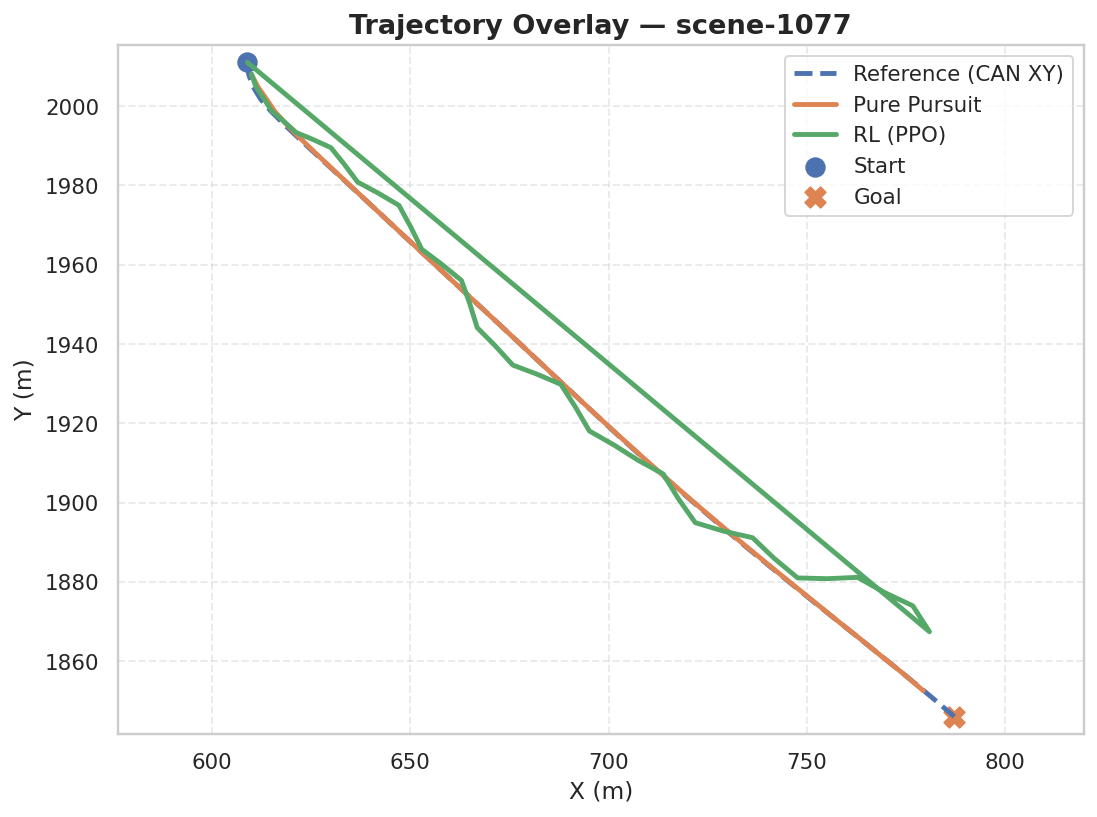

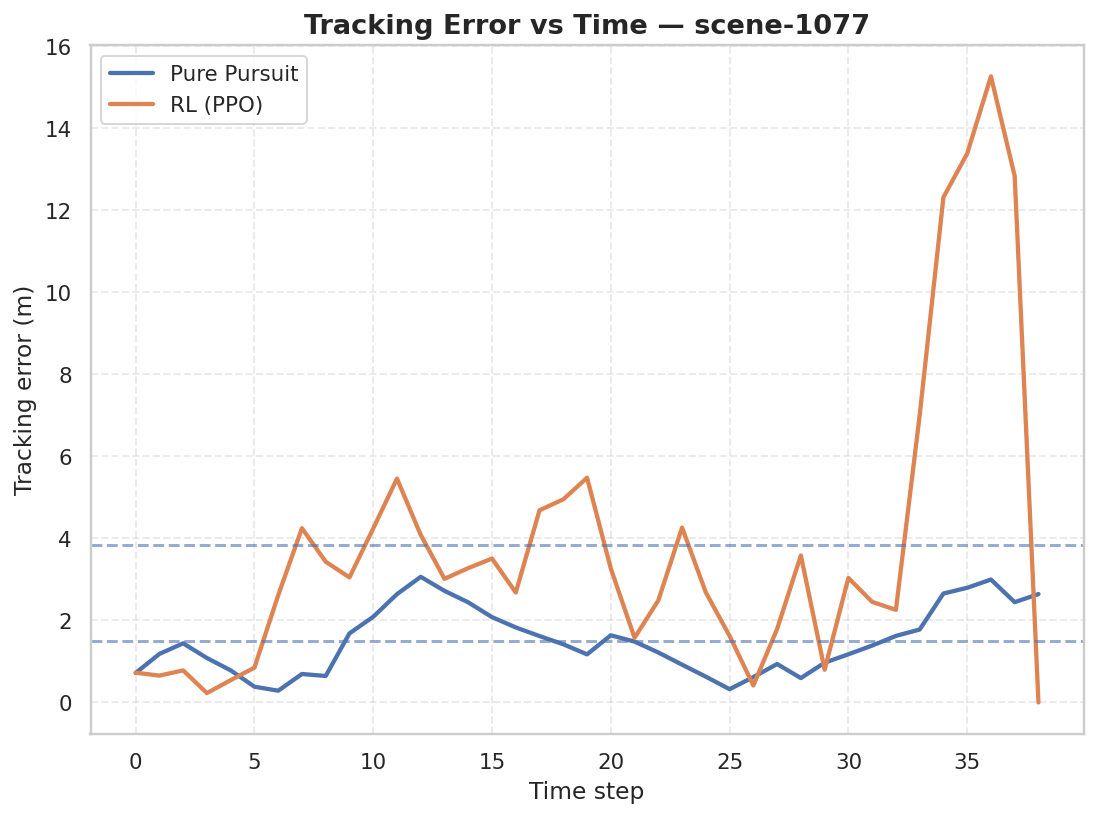


===== Evaluating scene-1094 =====
Pure Pursuit Mean Error: 1.284 m | Max: 7.220 m
RL (PPO) Mean Error:     2.803 m | Max: 7.434 m


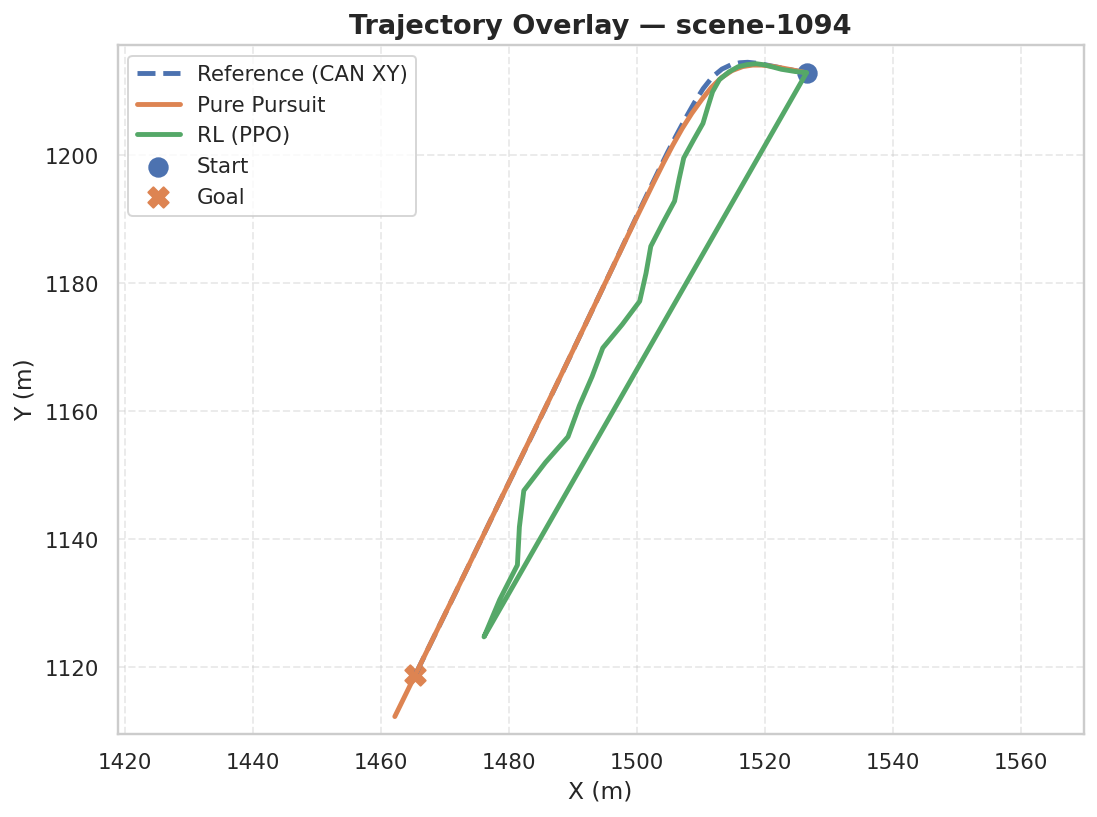

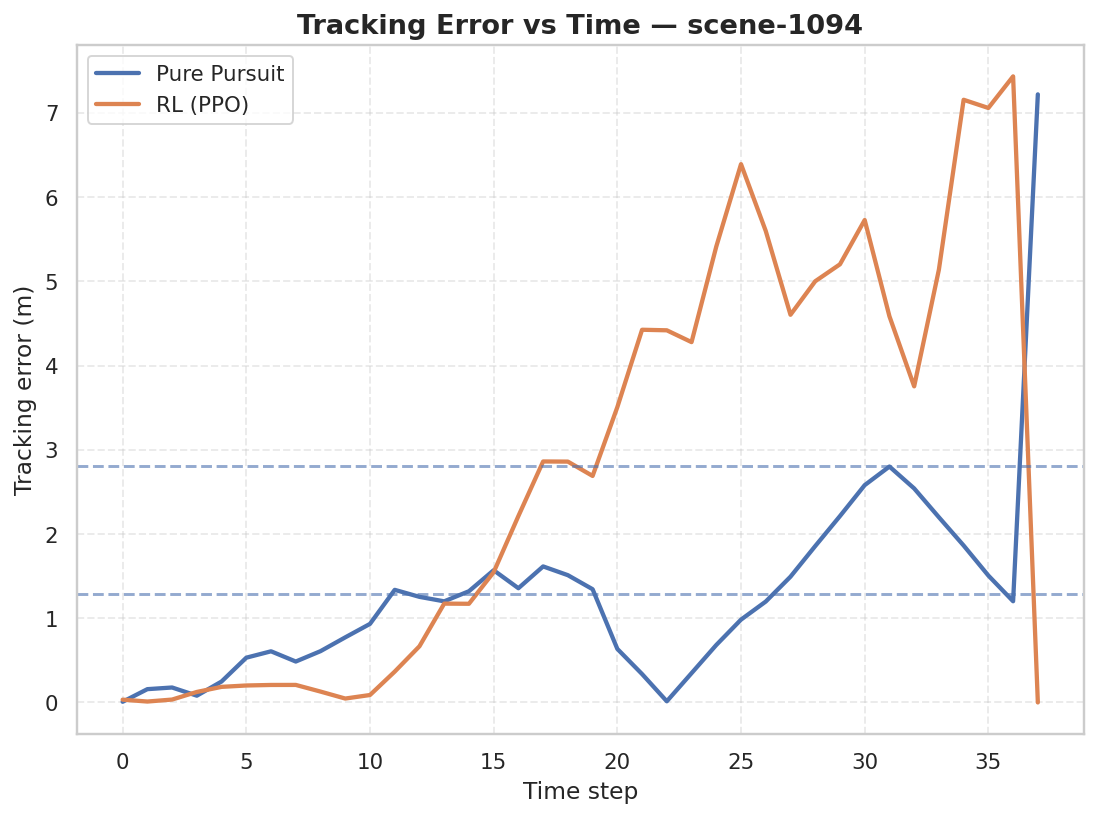


===== Evaluating scene-1100 =====
Pure Pursuit Mean Error: 0.000 m | Max: 0.000 m
RL (PPO) Mean Error:     0.598 m | Max: 1.930 m


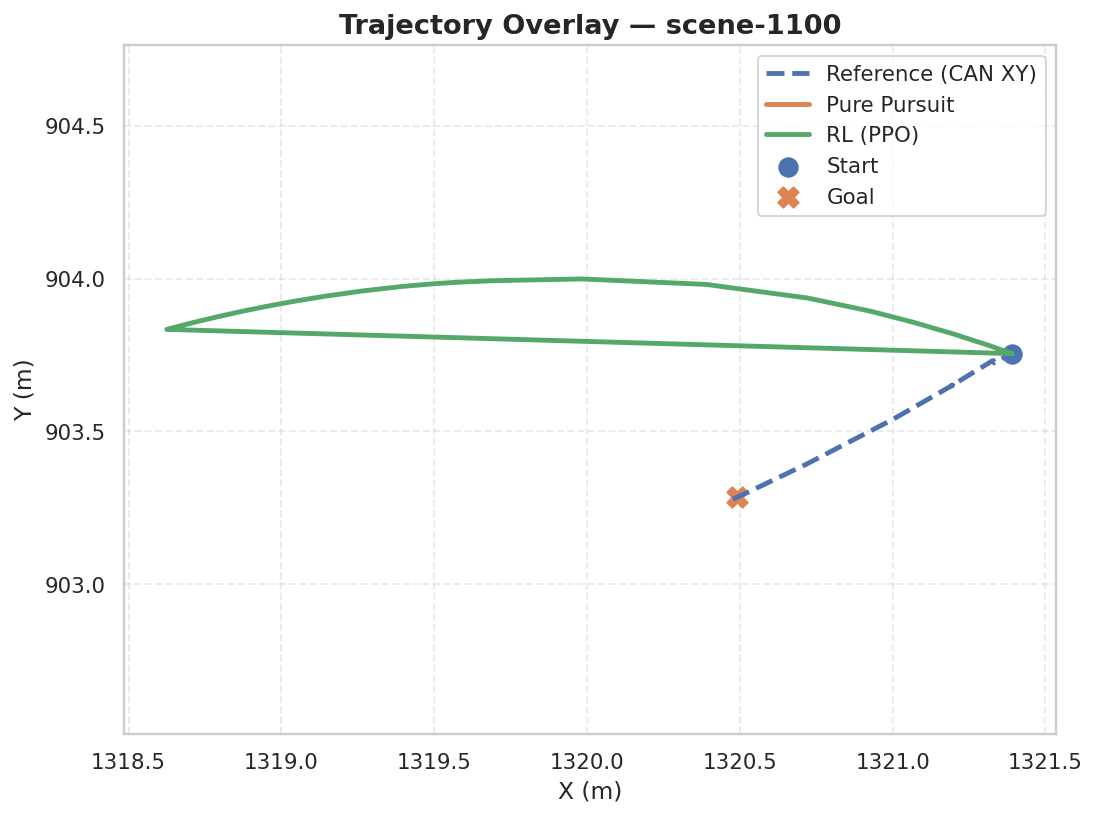

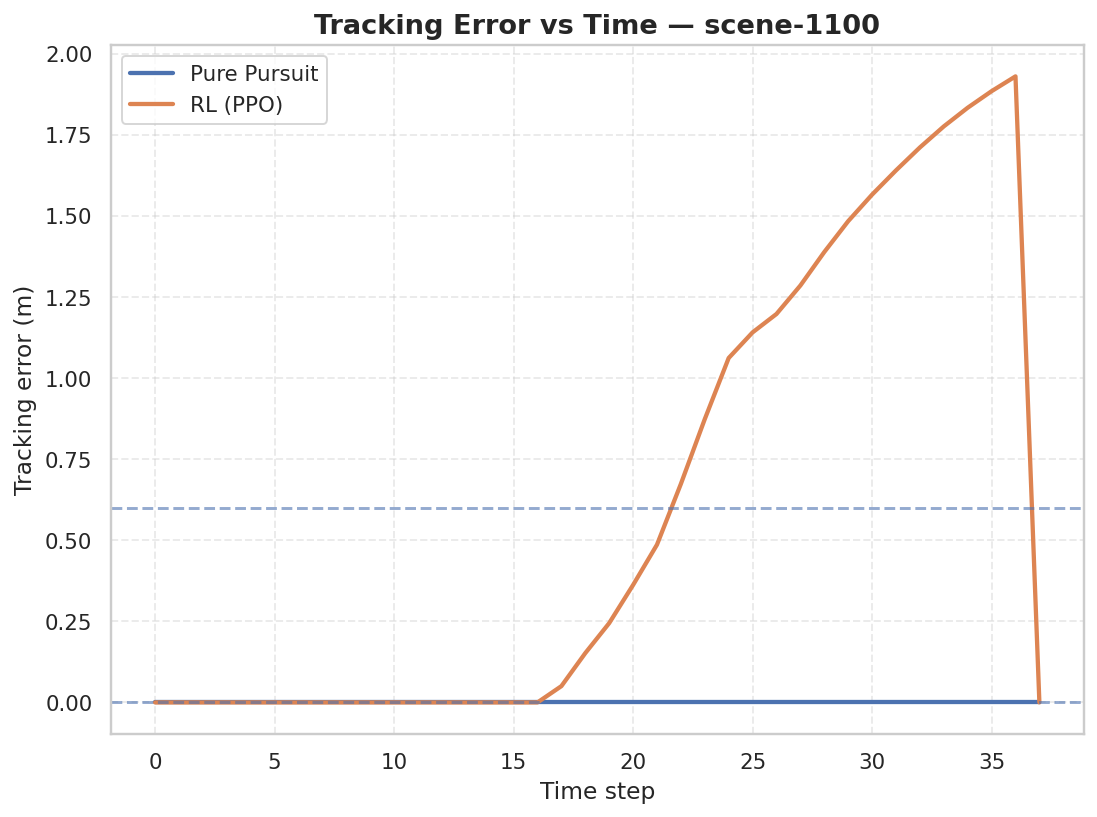


=== Summary Table ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,scene,pp_mean_m,pp_max_m,pp_steps,rl_mean_m,rl_max_m,rl_steps
0,scene-1077,1.507044,3.061129,39,3.832247,15.258052,39
1,scene-1094,1.283992,7.220182,38,2.802821,7.433685,38
2,scene-1100,0.000000,0.000000,38,0.598360,1.929803,38



Avg PP mean error:  0.930 m
Avg PPO mean error: 2.411 m


In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.monitor import Monitor


def evaluate_scene_with_vecnorm_can(
    scene_name: str,
    ppo_model,
    vecnorm_path: str,
    dt: float = 0.5,
    seed: int = 0,
    lookahead: float = 5.0,
    save_dir: str = "./eval_plots",
):
    os.makedirs(save_dir, exist_ok=True)
    print(f"\n===== Evaluating {scene_name} =====")

    # Reference from CAN-augmented traj_db
    assert scene_name in traj_db, f"{scene_name} not found in traj_db."
    states_can, timestamps = traj_db[scene_name]
    states_can = np.asarray(states_can, dtype=np.float32)

    # Reference path for plot: XY
    ref_xy = states_can[:, :2].copy()

    # Pure Pursuit rollout (no normalization)
    env_pp = MultiSceneTrajectoryTrackingEnv(
        traj_db={scene_name: (states_can, timestamps)},
        scene_list=[scene_name],
        weights=weights,
        dt=dt,
        seed=seed,
    )
    pp_controller = PurePursuitController(lookahead_distance=lookahead)

    obs, info = env_pp.reset(seed=seed)
    pp_controller.set_reference(env_pp.ref_states)

    pp_xy = []
    while True:
        action = pp_controller.get_action(env_pp.state)  # true state [x,y,v,psi]
        obs, reward, terminated, truncated, info = env_pp.step(action)
        pp_xy.append(env_pp.state[:2].copy())
        if terminated or truncated:
            break
    pp_xy = np.asarray(pp_xy, dtype=np.float32)

    # PPO rollout (VecNormalize stats from training)
    def _make_env():
        return Monitor(
            MultiSceneTrajectoryTrackingEnv(
                traj_db={scene_name: (states_can, timestamps)},
                scene_list=[scene_name],
                weights=weights,
                dt=dt,
                seed=seed,
            )
        )

    env_rl = DummyVecEnv([_make_env])
    env_rl = VecNormalize.load(vecnorm_path, env_rl)
    env_rl.training = False
    env_rl.norm_reward = False

    obs = env_rl.reset()
    base_env = env_rl.envs[0].unwrapped

    rl_xy = []
    while True:
        action, _ = ppo_model.predict(obs, deterministic=True)
        obs, rewards, dones, infos = env_rl.step(action)
        rl_xy.append(base_env.state[:2].copy())
        if bool(dones[0]):
            break
    rl_xy = np.asarray(rl_xy, dtype=np.float32)

    # Errors (min distance to reference polyline points)
    pp_err = np.min(cdist(pp_xy, ref_xy), axis=1) if len(pp_xy) else np.array([np.nan])
    rl_err = np.min(cdist(rl_xy, ref_xy), axis=1) if len(rl_xy) else np.array([np.nan])

    pp_mean, rl_mean = float(np.nanmean(pp_err)), float(np.nanmean(rl_err))
    pp_max,  rl_max  = float(np.nanmax(pp_err)),  float(np.nanmax(rl_err))

    print(f"Pure Pursuit Mean Error: {pp_mean:.3f} m | Max: {pp_max:.3f} m")
    print(f"RL (PPO) Mean Error:     {rl_mean:.3f} m | Max: {rl_max:.3f} m")

    # Overlay plot
    plt.figure(figsize=(8, 6), dpi=140)
    plt.plot(ref_xy[:, 0], ref_xy[:, 1], "--", linewidth=2.5, label="Reference (CAN XY)")
    plt.plot(pp_xy[:, 0],  pp_xy[:, 1],  linewidth=2.5, label="Pure Pursuit")
    plt.plot(rl_xy[:, 0],  rl_xy[:, 1],  linewidth=2.5, label="RL (PPO)")
    plt.scatter(ref_xy[0, 0],  ref_xy[0, 1],  s=90, label="Start")
    plt.scatter(ref_xy[-1, 0], ref_xy[-1, 1], s=110, marker="X", label="Goal")
    plt.title(f"Trajectory Overlay — {scene_name}", fontsize=14, weight="bold")
    plt.xlabel("X (m)"); plt.ylabel("Y (m)")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.axis("equal")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"trajectory_overlay_{scene_name}.png"), dpi=180)
    plt.show()

    # Error vs time plot
    min_len = int(min(len(pp_err), len(rl_err)))
    t = np.arange(min_len)

    plt.figure(figsize=(8, 6), dpi=140)
    plt.plot(t, pp_err[:min_len], linewidth=2.2, label="Pure Pursuit")
    plt.plot(t, rl_err[:min_len], linewidth=2.2, label="RL (PPO)")
    plt.axhline(pp_mean, linestyle="--", alpha=0.6)
    plt.axhline(rl_mean, linestyle="--", alpha=0.6)
    plt.title(f"Tracking Error vs Time — {scene_name}", fontsize=14, weight="bold")
    plt.xlabel("Time step"); plt.ylabel("Tracking error (m)")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"error_curve_{scene_name}.png"), dpi=180)
    plt.show()

    return {
        "scene": scene_name,
        "pp_mean_m": pp_mean,
        "pp_max_m": pp_max,
        "pp_steps": int(len(pp_xy)),
        "rl_mean_m": rl_mean,
        "rl_max_m": rl_max,
        "rl_steps": int(len(rl_xy)),
    }


# For all test scenes
vecnorm_path = os.path.join(log_dir, "vecnormalize.pkl")
assert os.path.exists(vecnorm_path), f"Missing VecNormalize stats: {vecnorm_path}"

rows = []
for scene in test_scenes:
    rows.append(
        evaluate_scene_with_vecnorm_can(
            scene_name=scene,
            ppo_model=model,
            vecnorm_path=vecnorm_path,
            dt=DT,
            seed=0,
            lookahead=5.0,
            save_dir="./eval_plots",
        )
    )

df_eval = pd.DataFrame(rows)
print("\n=== Summary Table ===")
display(df_eval)

print(f"\nAvg PP mean error:  {df_eval['pp_mean_m'].mean():.3f} m")
print(f"Avg PPO mean error: {df_eval['rl_mean_m'].mean():.3f} m")

In [31]:
!apt-get install ffmpeg -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [32]:
import os
import numpy as np
import matplotlib.pyplot as plt
import imageio

from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.monitor import Monitor


def rollout_pp_and_ppo_states_can(
    scene_name: str,
    ppo_model,
    vecnorm_path: str,
    dt: float = 0.5,
    seed: int = 0,
    lookahead: float = 5.0,
):
    assert scene_name in traj_db, f"{scene_name} not found in traj_db."
    states_can, timestamps = traj_db[scene_name]
    states_can = np.asarray(states_can, dtype=np.float32)

    # Pure Pursuit (no VecNormalize)
    env_pp = MultiSceneTrajectoryTrackingEnv(
        traj_db={scene_name: (states_can, timestamps)},
        scene_list=[scene_name],
        weights=weights,
        dt=dt,
        seed=seed,
    )
    pp_ctrl = PurePursuitController(lookahead_distance=lookahead)

    obs, info = env_pp.reset(seed=seed)
    pp_ctrl.set_reference(env_pp.ref_states)

    pp_states = []
    while True:
        action = pp_ctrl.get_action(env_pp.state)  # uses true state [x,y,v,psi]
        obs, r, terminated, truncated, info = env_pp.step(action)
        pp_states.append(env_pp.state.copy())
        if terminated or truncated:
            break
    pp_states = np.asarray(pp_states, dtype=np.float32)

    # PPO (VecNormalize loaded)
    def _make_env():
        return Monitor(
            MultiSceneTrajectoryTrackingEnv(
                traj_db={scene_name: (states_can, timestamps)},
                scene_list=[scene_name],
                weights=weights,
                dt=dt,
                seed=seed,
            )
        )

    env_rl = DummyVecEnv([_make_env])
    env_rl = VecNormalize.load(vecnorm_path, env_rl)
    env_rl.training = False
    env_rl.norm_reward = False

    obs = env_rl.reset()
    base_env = env_rl.envs[0].unwrapped

    rl_states = []
    while True:
        action, _ = ppo_model.predict(obs, deterministic=True)
        obs, r, done_arr, infos = env_rl.step(action)
        rl_states.append(base_env.state.copy())
        if bool(done_arr[0]):
            break
    rl_states = np.asarray(rl_states, dtype=np.float32)

    return states_can, pp_states, rl_states


def export_side_by_side_gif_can(
    scene_name: str,
    ppo_model,
    vecnorm_path: str,
    dt: float = 0.5,
    seed: int = 0,
    lookahead: float = 5.0,
    fps: int = 10,
    out_dir: str = "./gifs",
    shift_pad: float = 40.0,
    max_frames: int | None = None,
):
    os.makedirs(out_dir, exist_ok=True)

    ref_states, pp_states, rl_states = rollout_pp_and_ppo_states_can(
        scene_name=scene_name,
        ppo_model=ppo_model,
        vecnorm_path=vecnorm_path,
        dt=dt,
        seed=seed,
        lookahead=lookahead,
    )

    ref_xy = ref_states[:, :2]
    pp_xy  = pp_states[:, :2]
    rl_xy  = rl_states[:, :2]

    # Side-by-side horizontal shift
    shift = float((ref_xy[:, 0].max() - ref_xy[:, 0].min()) + shift_pad)

    max_len = int(max(len(rl_xy), len(pp_xy)))
    if max_frames is not None:
        max_len = min(max_len, int(max_frames))

    # Fixed axis limits (prevents jitter)
    all_xy = np.vstack([
        ref_xy,
        rl_xy,
        pp_xy + np.array([shift, 0.0], dtype=np.float32),
        ref_xy + np.array([shift, 0.0], dtype=np.float32),
    ])
    xmin, ymin = all_xy.min(axis=0)
    xmax, ymax = all_xy.max(axis=0)
    pad = 15.0
    xmin -= pad; xmax += pad
    ymin -= pad; ymax += pad

    frames = []
    duration = 1.0 / float(fps)

    # Divider x position (between left and right panels)
    divider_x = float(ref_xy[:, 0].max() + shift_pad / 2.0)

    for k in range(1, max_len + 1):
        fig, ax = plt.subplots(figsize=(12, 7), dpi=120)

        # Reference paths (left: PPO, right: PP)
        ax.plot(ref_xy[:, 0], ref_xy[:, 1], "--", linewidth=2.0, label="Reference (Left)")
        ax.plot(ref_xy[:, 0] + shift, ref_xy[:, 1], "--", linewidth=2.0, label="Reference (Right)")

        # Start/Goal (both sides)
        ax.scatter(ref_xy[0, 0], ref_xy[0, 1], s=80, label="Start")
        ax.scatter(ref_xy[-1, 0], ref_xy[-1, 1], s=90, marker="X", label="Goal")
        ax.scatter(ref_xy[0, 0] + shift, ref_xy[0, 1], s=80)
        ax.scatter(ref_xy[-1, 0] + shift, ref_xy[-1, 1], s=90, marker="X")

        # PPO trajectory (Left)
        kk = min(k, len(rl_xy))
        if kk > 0:
            ax.plot(rl_xy[:kk, 0], rl_xy[:kk, 1], linewidth=2.8, label="RL (PPO)")

        # PP trajectory (Right)
        kk = min(k, len(pp_xy))
        if kk > 0:
            ax.plot(pp_xy[:kk, 0] + shift, pp_xy[:kk, 1], linewidth=2.8, label="Pure Pursuit")

        # Divider
        ax.axvline(x=divider_x, linestyle=":", alpha=0.5)

        ax.set_title(
            f"Side-by-Side Tracking — {scene_name} | PPO (Left) vs Pure Pursuit (Right)",
            fontsize=13,
            weight="bold",
        )
        ax.set_xlabel("X (m)")
        ax.set_ylabel("Y (m)")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True, linestyle="--", alpha=0.35)
        ax.legend(loc="upper left", fontsize=9)
        fig.tight_layout()

        fig.canvas.draw()
        frame_img = np.asarray(fig.canvas.buffer_rgba())[:, :, :3].copy()
        frames.append(frame_img)
        plt.close(fig)

    out_path = os.path.join(out_dir, f"RL_vs_PP_{scene_name}.gif")
    imageio.mimsave(out_path, frames, duration=duration)
    print("Saved GIF:", out_path)


# For all test scenes
vecnorm_path = os.path.join(log_dir, "vecnormalize.pkl")
assert os.path.exists(vecnorm_path), f"Missing VecNormalize stats: {vecnorm_path}"

for scene in test_scenes:
    export_side_by_side_gif_can(
        scene_name=scene,
        ppo_model=model,
        vecnorm_path=vecnorm_path,
        dt=DT,
        seed=0,
        lookahead=5.0,
        fps=10,
        out_dir="./gifs",
        max_frames=None,
    )

Saved GIF: ./gifs/RL_vs_PP_scene-1077.gif
Saved GIF: ./gifs/RL_vs_PP_scene-1094.gif
Saved GIF: ./gifs/RL_vs_PP_scene-1100.gif


## Deploying PPO Policy into a Simulator (MetaDrive ScenarioEnv)

To demonstrate real-time driving execution beyond the offline tracking environment, I deployed the trained PPO policy into:
- **MetaDrive ScenarioEnv** (nuScenes scenario assets)

Key steps:
- Building a proxy observation `[dx, dy, dv, dpsi, prev_acc, yaw_rate]` from MetaDrive vehicle pose + navigation checkpoints.
- Map PPO outputs `[acc_cmd, steer_cmd]` into MetaDrive normalized controls `[steer_norm, throttle_brake]`.
- Applying a lightweight **safety shield** to reduce off-road behavior.

Output:
- Executable rollouts
- Collision/off-road flags
- GIF trajectory visualization

In [33]:
# MetaDrive Integration Sanity Check

import metadrive
from metadrive.envs.scenario_env import ScenarioEnv

print("MetaDrive imported successfully.")
print("ScenarioEnv loaded:", ScenarioEnv)

MetaDrive imported successfully.
ScenarioEnv loaded: <class 'metadrive.envs.scenario_env.ScenarioEnv'>


In [34]:
# Loading trained PPO + VecNormalize

import os
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.monitor import Monitor

DT = 0.5
log_dir = "./logs_multiscene_dt05_fixed"

vec_path   = os.path.join(log_dir, "vecnormalize.pkl")
model_path = os.path.join(log_dir, "ppo_multiscene_final.zip")

assert os.path.exists(vec_path),   f"Missing VecNormalize stats: {vec_path}"
assert os.path.exists(model_path), f"Missing PPO model: {model_path}"
assert "traj_db" in globals() and len(traj_db) > 0, "traj_db not found or empty."
assert "test_scenes" in globals() and len(test_scenes) > 0, "test_scenes not found or empty."
assert "weights" in globals(), "weights dict not found."

def make_eval_env(scene_list, seed=123):
    def _init():
        env = MultiSceneTrajectoryTrackingEnv(
            traj_db=traj_db,
            scene_list=scene_list,
            weights=weights,
            dt=DT,
            seed=seed
        )
        return Monitor(env)
    return _init

# VecNormalize.load expects SAME vec-env wrapper structure as training
eval_venv = DummyVecEnv([make_eval_env(test_scenes, seed=123)])

# Loading normalization stats
eval_venv = VecNormalize.load(vec_path, eval_venv)
eval_venv.training = False
eval_venv.norm_reward = False

# Loading model
ppo_model = PPO.load(model_path, env=eval_venv)

# Quick smoke test
obs = eval_venv.reset()
action, _ = ppo_model.predict(obs, deterministic=True)
obs, reward, done, info = eval_venv.step(action)

print("Loaded PPO model + VecNormalize stats successfully.")
print("Obs shape:", np.asarray(obs).shape, "| Action:", action, "| Reward:", float(reward[0]))
print("Example scene:", info[0].get("scene_name", "N/A"), "| pos_error:", info[0].get("pos_error", None))

Loaded PPO model + VecNormalize stats successfully.
Obs shape: (1, 6) | Action: [[-0.10261842  0.18412085]] | Reward: 0.9040108323097229
Example scene: scene-1077 | pos_error: 0.7250570908832905


In [35]:
# MetaDrive Scenario Environment Setup

import os
import sys
import subprocess
from metadrive.envs.scenario_env import ScenarioEnv
from metadrive.engine.asset_loader import AssetLoader

def try_pull_metadrive_asset(asset_name: str = "nuscenes"):

    candidates = [
        [sys.executable, "-m", "metadrive.pull_asset", "--asset", asset_name],
        [sys.executable, "-m", "metadrive.pull_asset", asset_name],
        [sys.executable, "-m", "metadrive.pull_asset"],
    ]
    for cmd in candidates:
        try:
            print("Trying:", " ".join(cmd))
            out = subprocess.run(cmd, check=False, capture_output=True, text=True)
            print(out.stdout[-800:] if out.stdout else "")
            if out.returncode == 0:
                return True
        except Exception as e:
            print("Command failed:", e)
    return False

# 1) Locating MetaDrive nuScenes scenario asset directory
DATA_DIR = AssetLoader.file_path("nuscenes", unix_style=False)
print("MetaDrive scenario dataset directory:", DATA_DIR)
print("Directory exists:", os.path.exists(DATA_DIR))

# 2) If missing, trying to download/pull assets
if not os.path.exists(DATA_DIR):
    print("\n MetaDrive nuScenes scenario assets not found.")
    ok = try_pull_metadrive_asset("nuscenes")
    DATA_DIR = AssetLoader.file_path("nuscenes", unix_style=False)
    print("\nRe-check directory:", DATA_DIR)
    print("Directory exists:", os.path.exists(DATA_DIR))

# 3) Final assert with a helpful message
assert os.path.exists(DATA_DIR), (
    "MetaDrive nuScenes scenario assets are still missing.\n"
    "This usually means the asset download did not run in this environment.\n"
    "Fix options:\n"
    "  (A) Re-run the cell, or restart runtime and run again.\n"
    "  (B) Install MetaDrive from pip (often auto-downloads assets) and retry:\n"
    "      %pip -q install metadrive-simulator\n"
    "  (C) Provide a local ScenarioNet-compatible scenario directory and set data_directory to it.\n"
)

# 4) Creating ScenarioEnv
env_sim = ScenarioEnv(
    dict(
        use_render=False,
        manual_control=False,
        horizon=300,
        data_directory=DATA_DIR,
        num_scenarios=5,
        sequential_seed=True,
        reactive_traffic=False,
        no_traffic=True,
        log_level=50,
        force_destroy=True,
    )
)

print("MetaDrive ScenarioEnv created successfully.")

MetaDrive scenario dataset directory: /usr/local/lib/python3.12/dist-packages/metadrive/assets/nuscenes
Directory exists: True
MetaDrive ScenarioEnv created successfully.


In [36]:
import numpy as np
import matplotlib.pyplot as plt
import imageio

# Tunables
SMOOTH = 0.85                 # action smoothing (0=no smoothing, 0.85 stable)
DT_SIM = 0.5
MAX_STEER = 0.5               # PPO steer range (rad)
MAX_ACC = 3.0                 # PPO acc range (m/s^2)
TARGET_SPEED = 3.0            # m/s (safer transfer)
CHECKPOINT_LOOKAHEAD = 6      # checkpoint index to aim for
H = 300                       # rollout horizon
GIF_FPS = 15                  # GIF playback fps

def wrap_to_pi(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi

def map_ppo_action_to_metadrive(action_ppo, max_steer=MAX_STEER, max_acc=MAX_ACC):

    a = float(action_ppo[0])
    delta = float(action_ppo[1])
    steer_norm = np.clip(delta / max_steer, -1.0, 1.0)
    throttle_brake = np.clip(a / max_acc, -1.0, 1.0)
    return np.array([steer_norm, throttle_brake], dtype=np.float32)

def get_checkpoint_xy(env_sim, k=0):
    cps = getattr(env_sim.vehicle.navigation, "checkpoints", None)
    if cps is None or len(cps) == 0:
        return None
    idx = min(int(k), len(cps) - 1)
    cp = cps[idx]
    return float(cp[0]), float(cp[1])

def build_ppo_obs_from_metadrive(env_sim, prev_acc, prev_heading, dt=DT_SIM, target_speed=TARGET_SPEED):

    v = env_sim.vehicle
    x, y = float(v.position[0]), float(v.position[1])
    psi = float(v.heading_theta)
    speed = float(v.speed)

    cp = get_checkpoint_xy(env_sim, k=CHECKPOINT_LOOKAHEAD)
    if cp is None:
        x_ref, y_ref = x, y
        psi_ref = psi
    else:
        x_ref, y_ref = cp
        psi_ref = float(np.arctan2(y_ref - y, x_ref - x))

    dx = x - x_ref
    dy = y - y_ref
    dv = speed - float(target_speed)
    dpsi = float(wrap_to_pi(psi - psi_ref))

    yaw_rate = float(wrap_to_pi(psi - float(prev_heading)) / float(dt))

    obs = np.array([dx, dy, dv, dpsi, float(prev_acc), float(yaw_rate)], dtype=np.float32)
    return obs, psi

def safety_shield(action_sim, obs_ppo):

    dx, dy, dv, dpsi, prev_acc, yaw_rate = obs_ppo
    steer, throttle = float(action_sim[0]), float(action_sim[1])

    dist2 = float(dx * dx + dy * dy)

    # Conservative region
    if abs(float(dpsi)) > 0.6 or dist2 > (12.0 ** 2):
        steer *= 0.5
        throttle = min(throttle, 0.0)  # no positive accel

    # To keep within MetaDrive action range
    steer = float(np.clip(steer, -1.0, 1.0))
    throttle = float(np.clip(throttle, -1.0, 1.0))
    return np.array([steer, throttle], dtype=np.float32)

# Rollout + Record
positions = []
frames = []
total_reward = 0.0
collision = False
off_road = False

prev_acc = 0.0
action_sim_prev = np.array([0.0, 0.0], dtype=np.float32)

reset_out = env_sim.reset()
if isinstance(reset_out, tuple) and len(reset_out) == 2:
    obs_sim, info = reset_out
else:
    obs_sim, info = reset_out, {}

prev_heading = float(env_sim.vehicle.heading_theta)

try:
    for t in range(H):
        obs_ppo, prev_heading = build_ppo_obs_from_metadrive(env_sim, prev_acc, prev_heading)

        # PPO action in tracking-space
        action_ppo, _ = model.predict(obs_ppo, deterministic=True)
        prev_acc = float(action_ppo[0])

        # Map to MetaDrive action
        action_sim = map_ppo_action_to_metadrive(action_ppo)

        # Smooth action
        action_sim = SMOOTH * action_sim_prev + (1.0 - SMOOTH) * action_sim
        action_sim = np.clip(action_sim, -1.0, 1.0).astype(np.float32)
        action_sim_prev = action_sim

        # Safety shield
        action_sim = safety_shield(action_sim, obs_ppo)

        # Step MetaDrive
        step_out = env_sim.step(action_sim)
        if isinstance(step_out, tuple) and len(step_out) == 5:
            obs_sim, reward, terminated, truncated, info = step_out
            done = bool(terminated or truncated)
        else:
            obs_sim, reward, done, info = step_out

        total_reward += float(reward)

        x, y = env_sim.vehicle.position[:2]
        positions.append((float(x), float(y)))

        if isinstance(info, dict):
            collision = collision or bool(info.get("crash_vehicle", False) or info.get("crash", False))
            off_road  = off_road  or bool(info.get("out_of_road", False))

        if done:
            break

finally:
    env_sim.close()

positions = np.asarray(positions, dtype=np.float32)

print("Rollout steps:", int(len(positions)))
print("Total reward:", float(total_reward))
print("Collision:", bool(collision))
print("Off-road:", bool(off_road))

# Building GIF (trajectory animation)
if len(positions) == 0:
    raise RuntimeError("No positions recorded. Rollout ended immediately; cannot build GIF.")

for i in range(len(positions)):
    fig, ax = plt.subplots(figsize=(5, 5), dpi=120)
    ax.plot(positions[:i+1, 0], positions[:i+1, 1], linewidth=2)
    ax.scatter(positions[0, 0], positions[0, 1], s=60, label="Start")
    ax.scatter(positions[i, 0], positions[i, 1], s=60, label="Current")
    ax.set_aspect("equal", adjustable="box")
    ax.set_title("PPO Trajectory in MetaDrive (Safety Shield)")
    ax.grid(alpha=0.3)
    ax.legend(loc="best")
    fig.tight_layout()

    fig.canvas.draw()
    buf = np.asarray(fig.canvas.buffer_rgba())
    frames.append(buf[:, :, :3].copy())
    plt.close(fig)

gif_path = "ppo_metadrive_trajectory.gif"
imageio.mimsave(gif_path, frames, duration=1.0 / GIF_FPS)
print("GIF saved:", gif_path)

Rollout steps: 12
Total reward: -0.7302394601656426
Collision: False
Off-road: True
GIF saved: ppo_metadrive_trajectory.gif


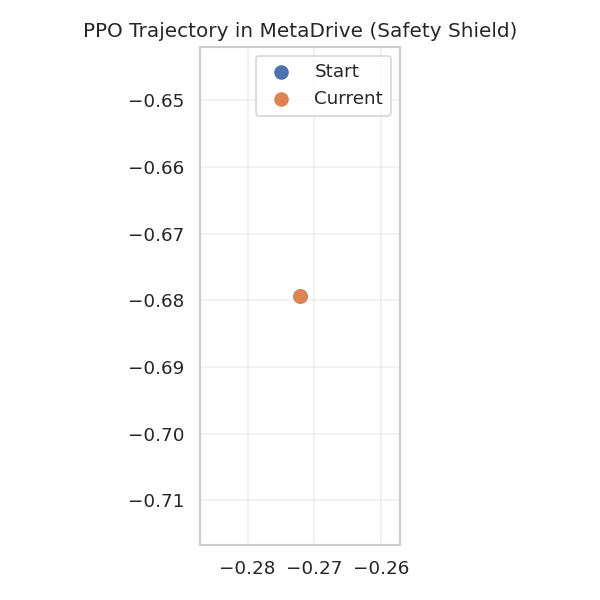

In [37]:
from IPython.display import Image, display
display(Image("ppo_metadrive_trajectory.gif"))

In [38]:
import numpy as np
import pandas as pd
import imageio
import matplotlib.pyplot as plt

from metadrive.envs.scenario_env import ScenarioEnv
from metadrive.engine.asset_loader import AssetLoader

HORIZON = 300
DT_SIM = 0.5

N_ROLLOUTS = 5
SAVE_GIFS = True
SAVE_GIF_EVERY = 1            # save a gif every k rollouts (1 = all)
GIF_FPS = 15

SMOOTH = 0.85
MAX_STEER = 0.5
MAX_ACC = 3.0
TARGET_SPEED = 3.0
CHECKPOINT_LOOKAHEAD = 6

def wrap_to_pi(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi

def map_ppo_action_to_metadrive(action_ppo, max_steer=MAX_STEER, max_acc=MAX_ACC):

    a = float(action_ppo[0])
    delta = float(action_ppo[1])
    steer_norm = np.clip(delta / max_steer, -1.0, 1.0)
    throttle_brake = np.clip(a / max_acc, -1.0, 1.0)
    return np.array([steer_norm, throttle_brake], dtype=np.float32)

def get_checkpoint_xy(env_sim, k=0):
    cps = getattr(env_sim.vehicle.navigation, "checkpoints", None)
    if cps is None or len(cps) == 0:
        return None
    k = int(np.clip(k, 0, len(cps) - 1))
    cp = cps[k]
    return float(cp[0]), float(cp[1])

def build_ppo_obs_from_metadrive(env_sim, prev_acc, prev_heading, dt=DT_SIM, target_speed=TARGET_SPEED):

    v = env_sim.vehicle
    x, y = float(v.position[0]), float(v.position[1])
    psi = float(v.heading_theta)
    speed = float(v.speed)

    cp = get_checkpoint_xy(env_sim, k=CHECKPOINT_LOOKAHEAD)
    if cp is None:
        x_ref, y_ref = x, y
        psi_ref = psi
    else:
        x_ref, y_ref = cp
        psi_ref = float(np.arctan2(y_ref - y, x_ref - x))

    dx = x - x_ref
    dy = y - y_ref
    dv = speed - float(target_speed)
    dpsi = wrap_to_pi(psi - psi_ref)

    yaw_rate = wrap_to_pi(psi - float(prev_heading)) / float(dt)

    obs = np.array([dx, dy, dv, dpsi, float(prev_acc), float(yaw_rate)], dtype=np.float32)
    return obs, psi

def safety_shield(action_sim, obs_ppo):

    dx, dy, dv, dpsi, prev_acc, yaw_rate = obs_ppo
    steer, throttle = float(action_sim[0]), float(action_sim[1])

    dist2 = float(dx * dx + dy * dy)
    if abs(float(dpsi)) > 0.6 or dist2 > (12.0 ** 2):
        steer *= 0.5
        throttle = min(throttle, 0.0)

    steer = float(np.clip(steer, -1.0, 1.0))
    throttle = float(np.clip(throttle, -1.0, 1.0))
    return np.array([steer, throttle], dtype=np.float32)


# Scenario env builder
DATA_DIR = AssetLoader.file_path("nuscenes", unix_style=False)
assert isinstance(DATA_DIR, str) and len(DATA_DIR) > 0, "Could not locate MetaDrive nuScenes asset directory."

def make_scenario_env(seed: int):
    env = ScenarioEnv(
        dict(
            use_render=False,
            manual_control=False,
            horizon=HORIZON,
            data_directory=DATA_DIR,
            num_scenarios=10,
            sequential_seed=True,
            reactive_traffic=False,
            no_traffic=False,
            log_level=50,
            force_destroy=True,
        )
    )

    try:
        env.reset(seed=seed)
    except TypeError:
        env.reset()
    return env


# Single rollout
def run_metadrive_rollout(seed: int, save_gif: bool = True, gif_path: str | None = None):
    env_sim = make_scenario_env(seed)

    positions = []
    frames = []
    total_reward = 0.0
    collision = False
    off_road = False

    prev_acc = 0.0
    action_sim_prev = np.array([0.0, 0.0], dtype=np.float32)

    reset_out = env_sim.reset()
    if isinstance(reset_out, tuple) and len(reset_out) == 2:
        obs_sim, info0 = reset_out
    else:
        obs_sim, info0 = reset_out, {}

    prev_heading = float(env_sim.vehicle.heading_theta)

    try:
        for t in range(HORIZON):
            obs_ppo, prev_heading = build_ppo_obs_from_metadrive(env_sim, prev_acc, prev_heading)


            action_ppo, _ = ppo_model.predict(obs_ppo, deterministic=True)
            prev_acc = float(action_ppo[0])

            action_sim = map_ppo_action_to_metadrive(action_ppo)

            # smooth action
            action_sim = SMOOTH * action_sim_prev + (1.0 - SMOOTH) * action_sim
            action_sim = np.clip(action_sim, -1.0, 1.0).astype(np.float32)
            action_sim_prev = action_sim

            # safety shield
            action_sim = safety_shield(action_sim, obs_ppo)

            step_out = env_sim.step(action_sim)
            if isinstance(step_out, tuple) and len(step_out) == 5:
                obs_sim, reward, terminated, truncated, info = step_out
                done = bool(terminated or truncated)
            else:
                obs_sim, reward, done, info = step_out

            total_reward += float(reward)

            x, y = env_sim.vehicle.position[:2]
            positions.append((float(x), float(y)))

            if isinstance(info, dict):
                collision = collision or bool(info.get("crash_vehicle", False) or info.get("crash", False))
                off_road = off_road or bool(info.get("out_of_road", False))

            if done:
                break
    finally:
        env_sim.close()

    positions = np.asarray(positions, dtype=np.float32)
    steps = int(len(positions))

    # success definition
    success = (steps >= HORIZON) and (not collision) and (not off_road)

    # Building GIF
    if save_gif:
        if gif_path is None:
            gif_path = f"ppo_metadrive_seed{seed}.gif"

        for i in range(steps):
            fig, ax = plt.subplots(figsize=(5, 5), dpi=120)
            ax.plot(positions[: i + 1, 0], positions[: i + 1, 1], linewidth=2)
            ax.scatter(positions[0, 0], positions[0, 1], s=60, label="Start")
            ax.scatter(positions[i, 0], positions[i, 1], s=60, label="Current")
            ax.set_aspect("equal", adjustable="box")
            ax.set_title(f"PPO in MetaDrive (seed={seed})")
            ax.grid(alpha=0.3)
            ax.legend(loc="best")
            fig.tight_layout()

            fig.canvas.draw()
            buf = np.asarray(fig.canvas.buffer_rgba())
            frames.append(buf[:, :, :3].copy())
            plt.close(fig)

        imageio.mimsave(gif_path, frames, duration=1.0 / GIF_FPS)
    else:
        gif_path = None

    metrics = {
        "seed": int(seed),
        "steps": int(steps),
        "total_reward": float(total_reward),
        "collision": bool(collision),
        "off_road": bool(off_road),
        "success": bool(success),
        "gif": gif_path,
    }
    return metrics, positions


# Multiple rollouts + report table
results = []
trajectories = {}

base_seed = 0
for i in range(N_ROLLOUTS):
    seed = int(base_seed + i)
    save_this_gif = bool(SAVE_GIFS and (i % SAVE_GIF_EVERY == 0))
    metrics, pos = run_metadrive_rollout(seed, save_gif=save_this_gif)
    results.append(metrics)
    trajectories[seed] = pos

df = pd.DataFrame(results)
df["success_rate"] = df["success"].mean()

print("=== MetaDrive Multi-Seed Summary ===")
print(f"Rollouts: {len(df)} | Success rate: {df['success'].mean():.2f}")
display(df)

agg = pd.DataFrame([{
    "rollouts": int(len(df)),
    "success_rate": float(df["success"].mean()),
    "mean_steps": float(df["steps"].mean()),
    "mean_reward": float(df["total_reward"].mean()),
    "collisions": int(df["collision"].sum()),
    "off_road": int(df["off_road"].sum()),
}])
display(agg)

=== MetaDrive Multi-Seed Summary ===
Rollouts: 5 | Success rate: 0.00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,seed,steps,total_reward,collision,off_road,success,gif,success_rate
0,0,12,-12.589614,False,True,False,ppo_metadrive_seed0.gif,0.0
1,1,1,5.000000,False,True,False,ppo_metadrive_seed1.gif,0.0
2,2,16,-10.681688,False,True,False,ppo_metadrive_seed2.gif,0.0
3,3,36,-20.348276,True,True,False,ppo_metadrive_seed3.gif,0.0
4,4,12,1.168313,False,True,False,ppo_metadrive_seed4.gif,0.0


,rollouts,success_rate,mean_steps,mean_reward,collisions,off_road
0,5,0.0,15.4,-7.490253,1,5


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [39]:
# MetaDrive Deployment (No Traffic) – Controlled Transfer Test

import numpy as np
import pandas as pd
from metadrive.envs.scenario_env import ScenarioEnv
from metadrive.engine.asset_loader import AssetLoader

HORIZON = 300
N_ROLLOUTS = 5

DATA_DIR = AssetLoader.file_path("nuscenes", unix_style=False)

def make_scenario_env_no_traffic(seed: int):
    env = ScenarioEnv(
        dict(
            use_render=False,
            manual_control=False,
            horizon=HORIZON,
            data_directory=DATA_DIR,
            num_scenarios=10,
            sequential_seed=True,
            reactive_traffic=False,
            no_traffic=True,          # NO TRAFFIC
            log_level=50,
            force_destroy=True,
        )
    )
    try:
        env.reset(seed=seed)
    except TypeError:
        env.reset()
    return env


def run_no_traffic_rollout(seed: int):
    env = make_scenario_env_no_traffic(seed)

    total_reward = 0.0
    collision = False
    off_road = False

    prev_acc = 0.0
    action_prev = np.array([0.0, 0.0], dtype=np.float32)

    obs = env.reset()
    if isinstance(obs, tuple):
        obs = obs[0]

    prev_heading = float(env.vehicle.heading_theta)

    for t in range(HORIZON):

        obs_ppo, prev_heading = build_ppo_obs_from_metadrive(
            env, prev_acc, prev_heading
        )

        action_ppo, _ = ppo_model.predict(obs_ppo, deterministic=True)
        prev_acc = float(action_ppo[0])

        action_sim = map_ppo_action_to_metadrive(action_ppo)
        action_sim = 0.85 * action_prev + 0.15 * action_sim
        action_prev = action_sim

        action_sim = safety_shield(action_sim, obs_ppo)

        step_out = env.step(action_sim)

        if isinstance(step_out, tuple) and len(step_out) == 5:
            obs, reward, terminated, truncated, info = step_out
            done = terminated or truncated
        else:
            obs, reward, done, info = step_out

        total_reward += float(reward)

        if isinstance(info, dict):
            collision = collision or bool(info.get("crash_vehicle", False))
            off_road = off_road or bool(info.get("out_of_road", False))

        if done:
            break

    env.close()

    success = (not collision) and (not off_road)

    return {
        "seed": seed,
        "total_reward": total_reward,
        "collision": collision,
        "off_road": off_road,
        "success": success,
    }


# Run multiple seeds

results_no_traffic = []
for i in range(N_ROLLOUTS):
    results_no_traffic.append(run_no_traffic_rollout(seed=i))

df_no_traffic = pd.DataFrame(results_no_traffic)

print("=== MetaDrive (No Traffic) Results ===")
display(df_no_traffic)

print("\nSuccess rate:",
      100 * df_no_traffic["success"].mean(), "%")

=== MetaDrive (No Traffic) Results ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,seed,total_reward,collision,off_road,success
0,0,-12.589614,False,True,False
1,1,5.000000,False,True,False
2,2,-10.681688,False,True,False
3,3,1.651724,False,False,True
4,4,1.168313,False,True,False



Success rate: 20.0 %


### Trained Agent Behavior (All 10 Scenes)
GIF visualizations of PPO rollout per scene.

###Training Reward Curve
Episode reward progression during PPO training over time.

In [40]:
import os
import numpy as np
import matplotlib.pyplot as plt
import imageio

from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.monitor import Monitor

OUT_DIR = "gifs_all_scenes"
FPS = 10
DT = 0.5

os.makedirs(OUT_DIR, exist_ok=True)

all_scenes = list(traj_db.keys())
print("Generating GIFs for scenes:", all_scenes)

def rollout_ppo_xy_one_scene(scene_name: str, model, vecnorm_path: str, dt: float = 0.5, seed: int = 0):
    """Rollout PPO on ONE scene using VecNormalize stats. Returns (ref_xy, rl_xy)."""

    # Reference from traj_db (CAN or non-CAN both OK: x,y are cols 0,1)
    states, _ = traj_db[scene_name]
    states = np.asarray(states, dtype=np.float32)
    ref_xy = states[:, :2].copy()

    # Building 1-scene env
    def _make_env():
        env = MultiSceneTrajectoryTrackingEnv(
            traj_db={scene_name: (states, None)},
            scene_list=[scene_name],
            weights=weights,
            dt=dt,
            seed=seed
        )
        return Monitor(env)

    venv = DummyVecEnv([_make_env])

    # Loading VecNormalize stats
    venv = VecNormalize.load(vecnorm_path, venv)
    venv.training = False
    venv.norm_reward = False

    obs = venv.reset()
    base_env = venv.envs[0].unwrapped

    rl_xy = []
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, r, done_arr, infos = venv.step(action)
        rl_xy.append(base_env.state[:2].copy())
        done = bool(done_arr[0])

    rl_xy = np.asarray(rl_xy, dtype=np.float32)
    return ref_xy, rl_xy

def save_scene_gif(scene_name: str, ref_xy: np.ndarray, rl_xy: np.ndarray, out_dir: str, fps: int = 10):
    """Make a trajectory-progress GIF for one scene."""

    frames = []
    n = len(rl_xy)
    if n < 2:
        print(f"Skipping {scene_name} (too few steps).")
        return

    # Stable axis limits
    all_xy = np.vstack([ref_xy, rl_xy])
    xmin, ymin = all_xy.min(axis=0)
    xmax, ymax = all_xy.max(axis=0)
    pad = 10.0
    xmin -= pad; xmax += pad
    ymin -= pad; ymax += pad

    for k in range(1, n + 1):
        fig, ax = plt.subplots(figsize=(6, 6), dpi=120)
        ax.plot(ref_xy[:, 0], ref_xy[:, 1], "--", linewidth=2.0, label="Reference")
        ax.plot(rl_xy[:k, 0], rl_xy[:k, 1], "-", linewidth=2.5, label="PPO")
        ax.scatter(ref_xy[0, 0], ref_xy[0, 1], s=60, label="Start")
        ax.scatter(ref_xy[-1, 0], ref_xy[-1, 1], s=80, marker="X", label="Goal")

        ax.set_title(f"PPO Tracking — {scene_name}")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.3)
        ax.legend(loc="best", fontsize=9)
        fig.tight_layout()

        fig.canvas.draw()
        frame = np.asarray(fig.canvas.buffer_rgba())[:, :, :3].copy()
        frames.append(frame)
        plt.close(fig)

    gif_path = os.path.join(out_dir, f"{scene_name}.gif")
    imageio.mimsave(gif_path, frames, duration=1.0 / fps)
    print("Saved:", gif_path)


# For all scenes
for scene_name in all_scenes:
    ref_xy, rl_xy = rollout_ppo_xy_one_scene(scene_name, model, vecnorm_path, dt=DT, seed=0)
    save_scene_gif(scene_name, ref_xy, rl_xy, OUT_DIR, fps=FPS)

print("\nDone. GIFs saved in:", OUT_DIR)

Generating GIFs for scenes: ['scene-0061', 'scene-0103', 'scene-0553', 'scene-0655', 'scene-0757', 'scene-0796', 'scene-0916', 'scene-1077', 'scene-1094', 'scene-1100']
Saved: gifs_all_scenes/scene-0061.gif
Saved: gifs_all_scenes/scene-0103.gif
Saved: gifs_all_scenes/scene-0553.gif
Saved: gifs_all_scenes/scene-0655.gif
Saved: gifs_all_scenes/scene-0757.gif
Saved: gifs_all_scenes/scene-0796.gif
Saved: gifs_all_scenes/scene-0916.gif
Saved: gifs_all_scenes/scene-1077.gif
Saved: gifs_all_scenes/scene-1094.gif
Saved: gifs_all_scenes/scene-1100.gif

Done. GIFs saved in: gifs_all_scenes


Generating reward curves for scenes: ['scene-0061', 'scene-0103', 'scene-0553', 'scene-0655', 'scene-0757', 'scene-0796', 'scene-0916', 'scene-1077', 'scene-1094', 'scene-1100']


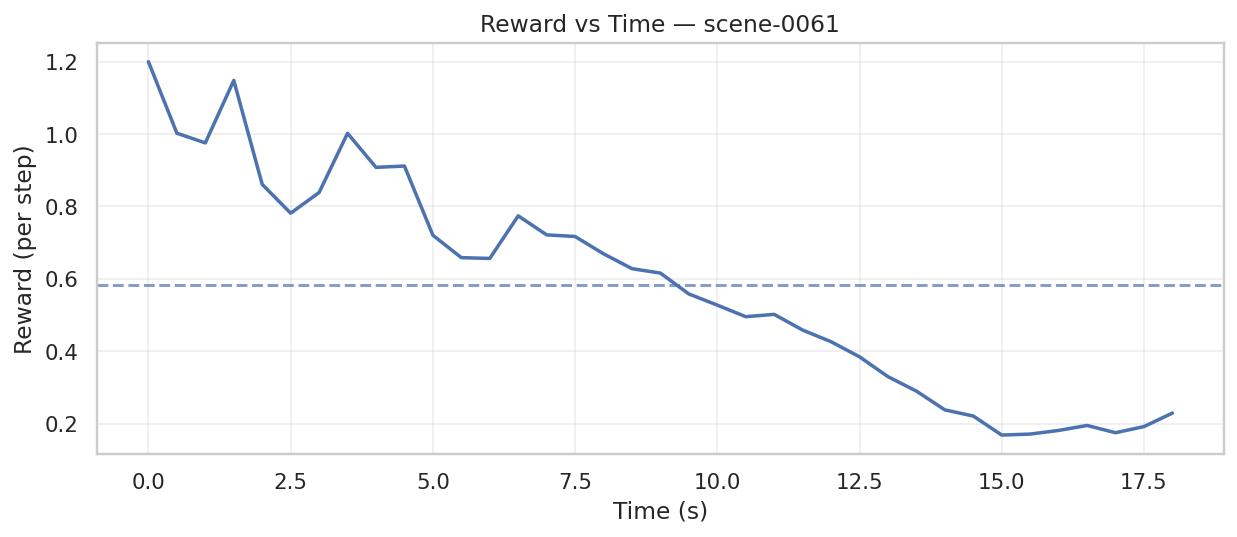

Saved: reward_curves_all_scenes/reward_curve_scene-0061.png


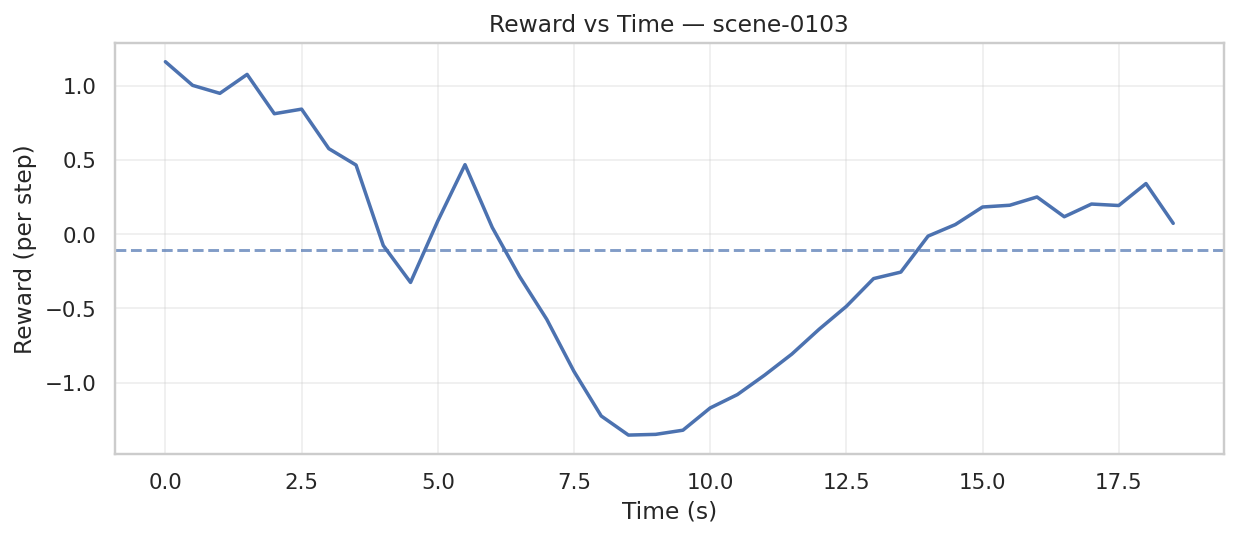

Saved: reward_curves_all_scenes/reward_curve_scene-0103.png


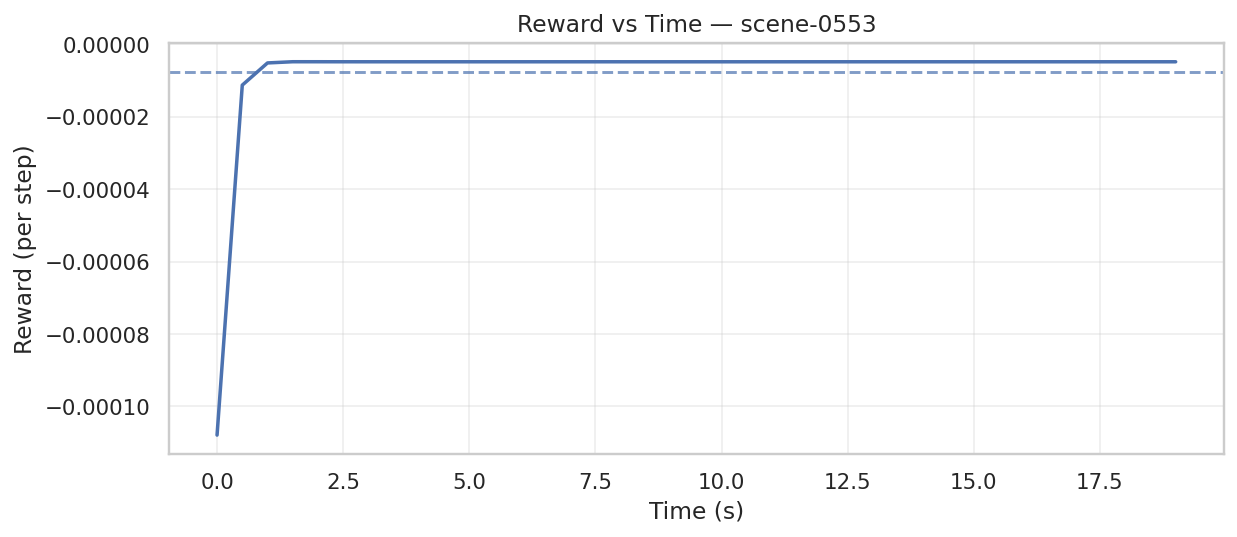

Saved: reward_curves_all_scenes/reward_curve_scene-0553.png


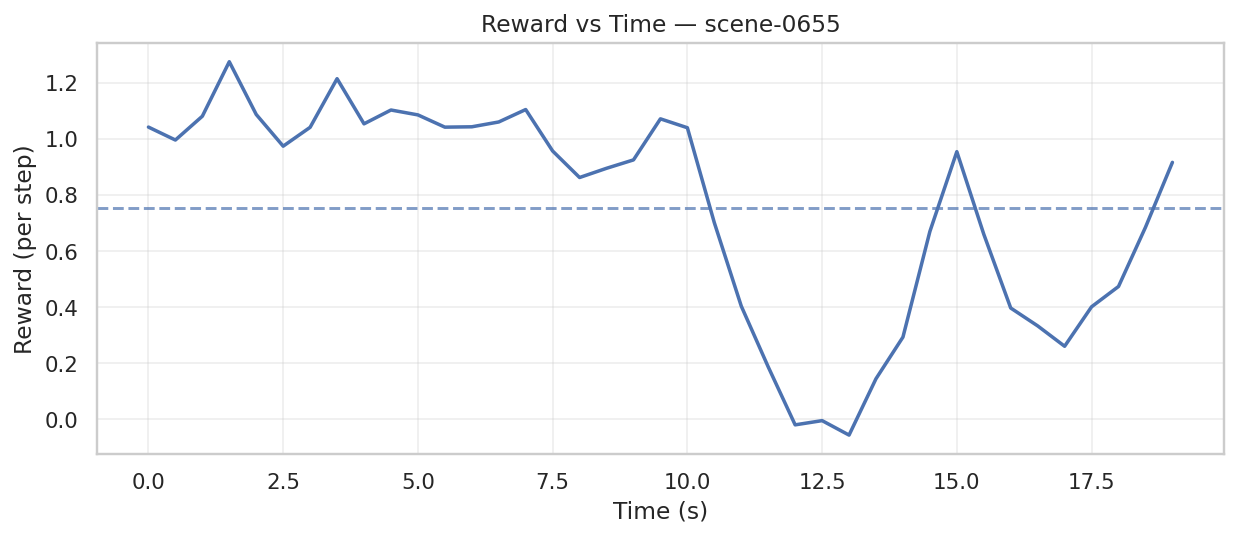

Saved: reward_curves_all_scenes/reward_curve_scene-0655.png


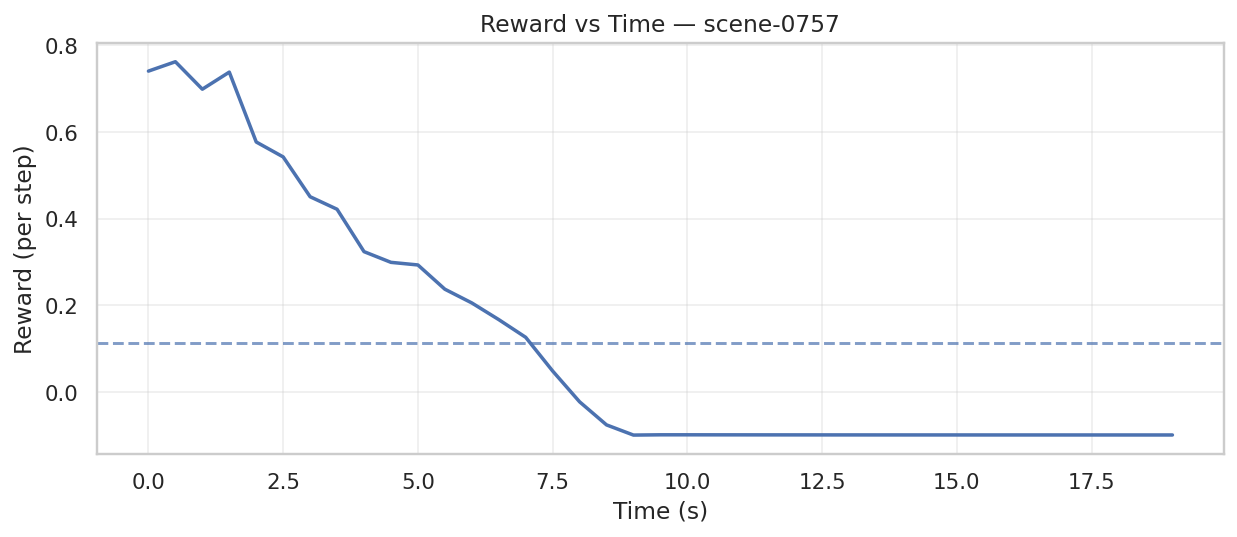

Saved: reward_curves_all_scenes/reward_curve_scene-0757.png


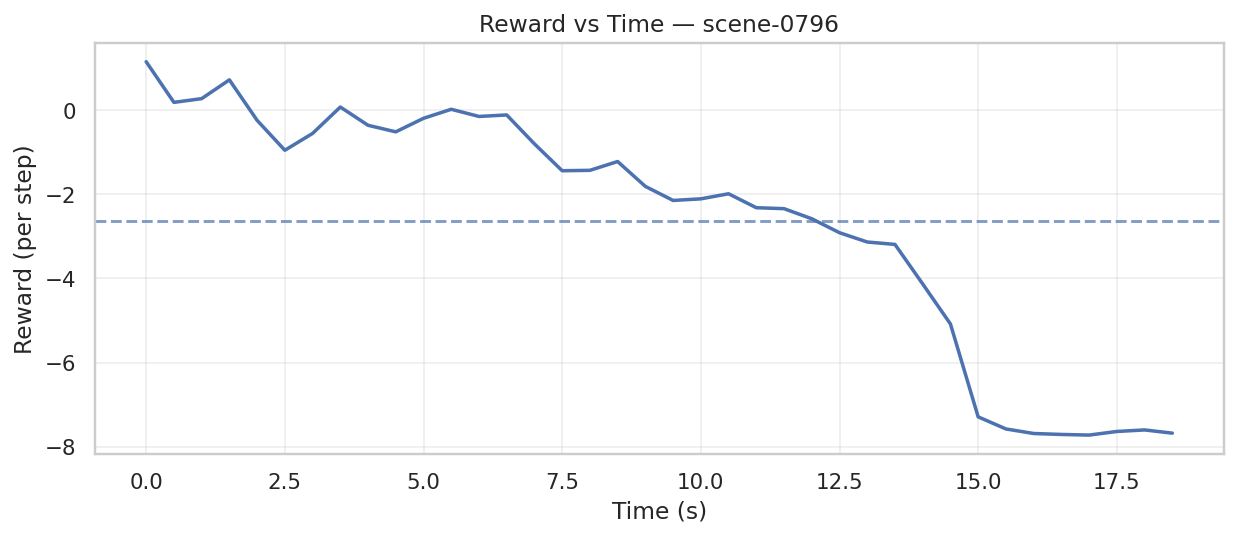

Saved: reward_curves_all_scenes/reward_curve_scene-0796.png


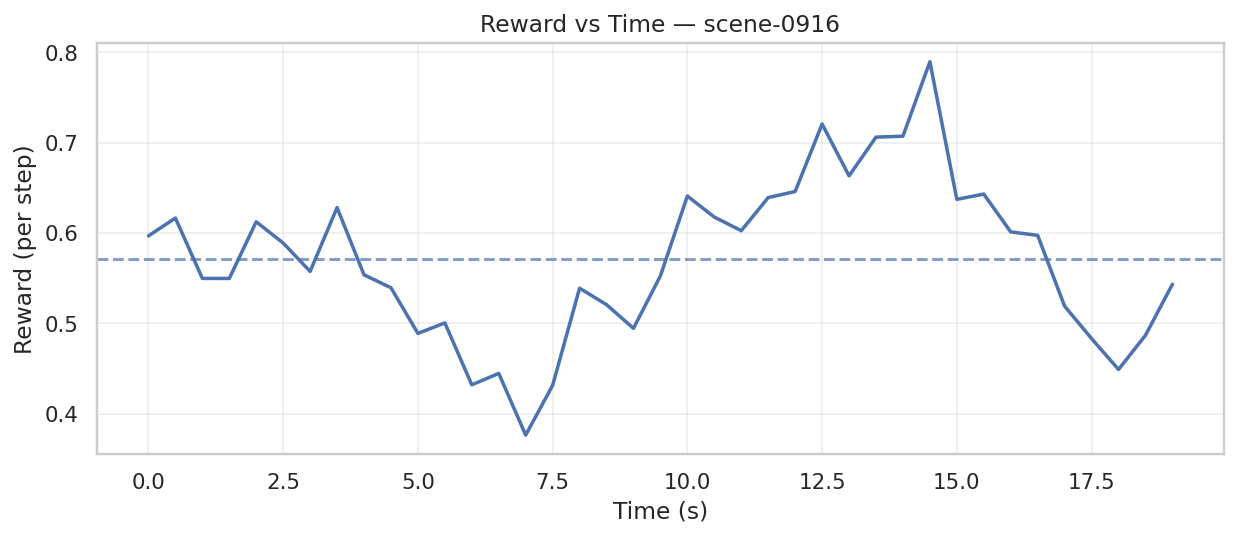

Saved: reward_curves_all_scenes/reward_curve_scene-0916.png


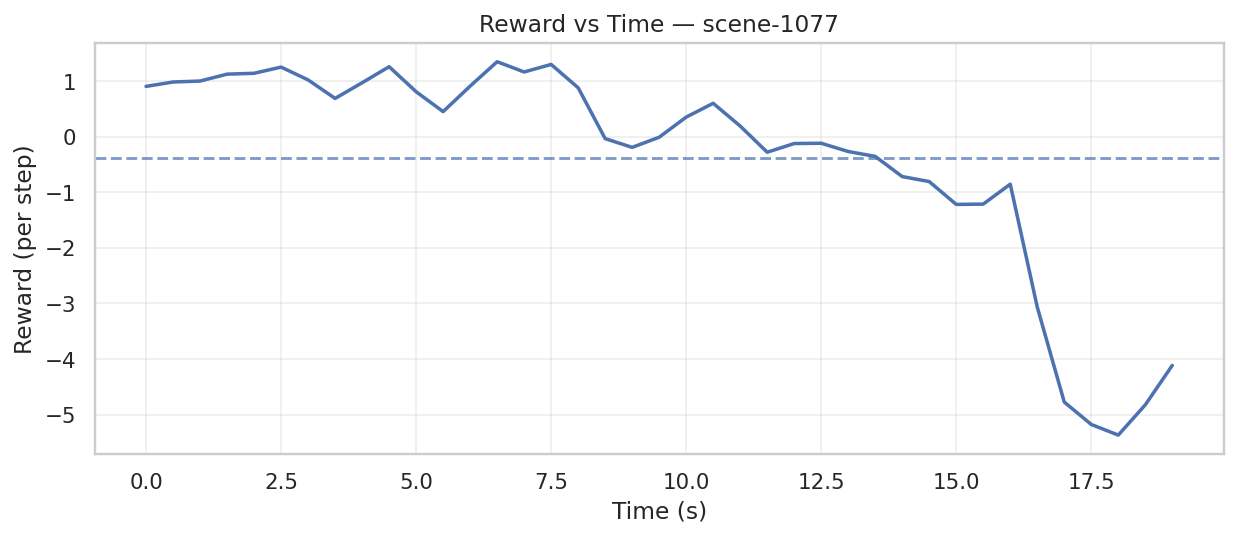

Saved: reward_curves_all_scenes/reward_curve_scene-1077.png


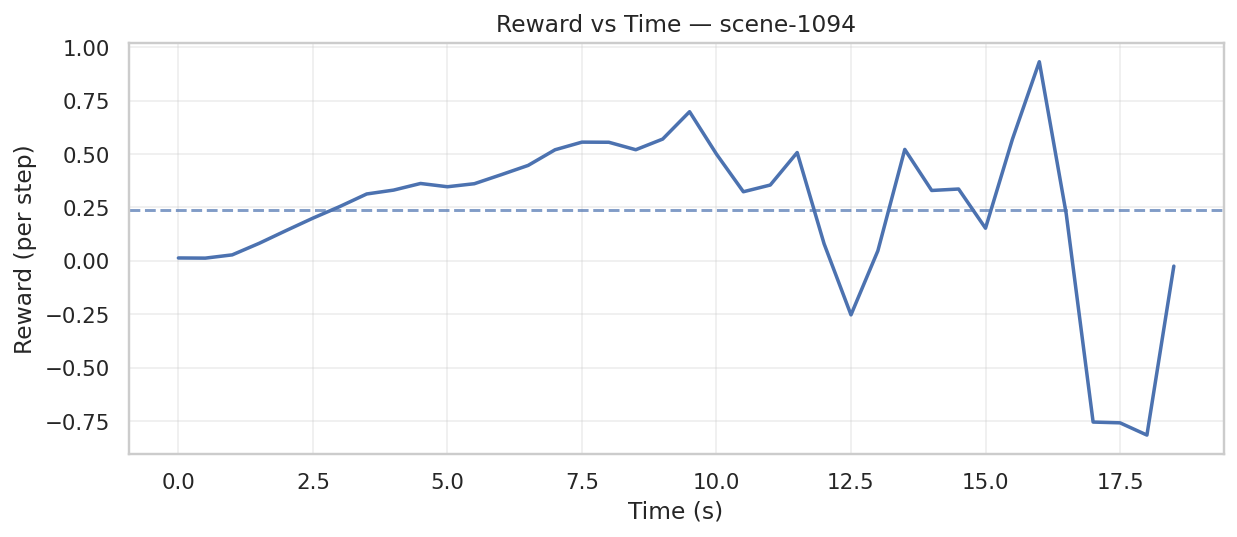

Saved: reward_curves_all_scenes/reward_curve_scene-1094.png


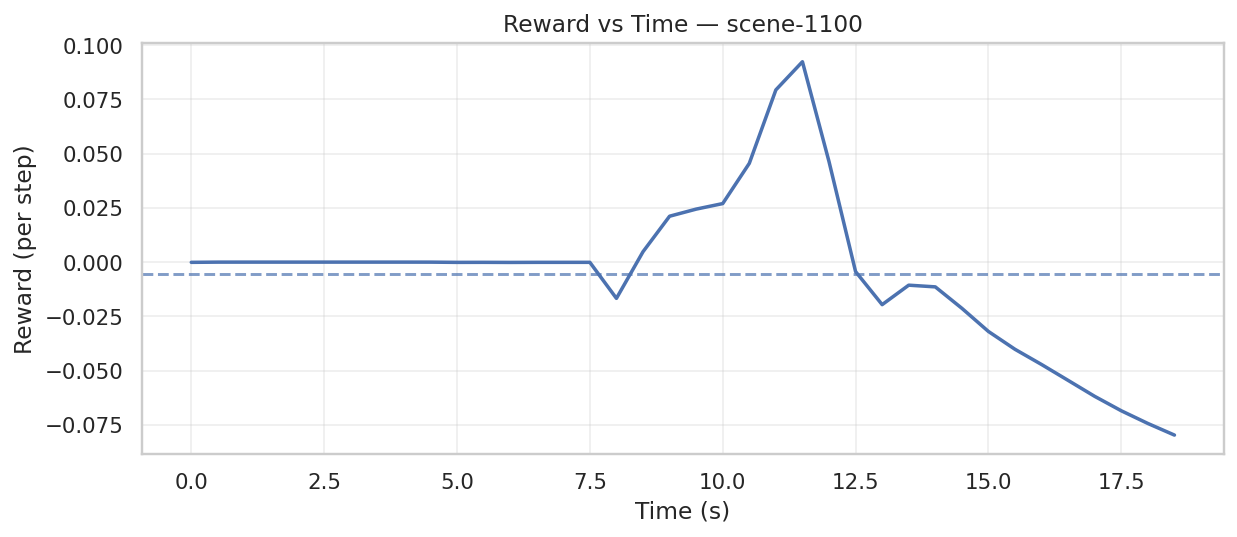

Saved: reward_curves_all_scenes/reward_curve_scene-1100.png

=== Per-scene reward summary ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,scene,steps,episode_return,mean_step_reward,mean_pos_error_m
0,scene-0061,37,21.531801,0.581941,2.044015
1,scene-0103,38,-4.061398,-0.106879,5.326289
2,scene-0553,39,-0.000298,-0.000008,0.000028
3,scene-0655,39,29.332235,0.752109,3.071016
4,scene-0757,39,4.450003,0.114103,1.917945
5,scene-0796,38,-100.083939,-2.633788,18.218385
6,scene-0916,39,22.259239,0.570750,2.034275
7,scene-1077,39,-15.189571,-0.389476,6.534337
8,scene-1094,38,8.987456,0.236512,3.270685
9,scene-1100,38,-0.202518,-0.005329,0.669729


Saved summary CSV: reward_curves_all_scenes/reward_summary.csv
Done. Reward plots folder: reward_curves_all_scenes


In [41]:
# Reward-over-time plots for ALL scenes (PPO, per-scene)

import os
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.monitor import Monitor

DT = 0.5
OUT_DIR = "reward_curves_all_scenes"
os.makedirs(OUT_DIR, exist_ok=True)

all_scenes = list(traj_db.keys())
print("Generating reward curves for scenes:", all_scenes)

def rollout_rewards_one_scene(scene_name: str, model, vecnorm_path: str, dt: float = 0.5, seed: int = 0):
    """
    Rollout PPO on ONE scene using VecNormalize stats.
    Returns: time_sec (T,), rewards (T,), episode_return (float), mean_pos_error (float)
    """
    states, ts = traj_db[scene_name]
    states = np.asarray(states, dtype=np.float32)

    def _make_env():
        env = MultiSceneTrajectoryTrackingEnv(
            traj_db={scene_name: (states, ts)},
            scene_list=[scene_name],
            weights=weights,
            dt=dt,
            seed=seed
        )
        return Monitor(env)

    venv = DummyVecEnv([_make_env])

    # Loading VecNormalize stats
    venv = VecNormalize.load(vecnorm_path, venv)
    venv.training = False
    venv.norm_reward = False

    obs = venv.reset()

    rewards = []
    pos_errs = []
    done = False
    step = 0

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, r, done_arr, infos = venv.step(action)

        rewards.append(float(r[0]))
        info0 = infos[0] if isinstance(infos, (list, tuple)) else infos
        if isinstance(info0, dict) and ("pos_error" in info0):
            pos_errs.append(float(info0["pos_error"]))

        done = bool(done_arr[0])
        step += 1

    rewards = np.asarray(rewards, dtype=np.float32)
    t_sec = np.arange(len(rewards), dtype=np.float32) * float(dt)

    ep_ret = float(np.sum(rewards))
    mean_pos = float(np.mean(pos_errs)) if len(pos_errs) else float("nan")
    return t_sec, rewards, ep_ret, mean_pos


def save_reward_plot(scene_name: str, t_sec: np.ndarray, rewards: np.ndarray, out_dir: str):
    plt.figure(figsize=(9, 4), dpi=140)
    plt.plot(t_sec, rewards, linewidth=1.8)
    plt.axhline(float(np.mean(rewards)), linestyle="--", alpha=0.7)
    plt.title(f"Reward vs Time — {scene_name}")
    plt.xlabel("Time (s)")
    plt.ylabel("Reward (per step)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    out_path = os.path.join(out_dir, f"reward_curve_{scene_name}.png")
    plt.savefig(out_path, dpi=180)
    plt.show()
    print("Saved:", out_path)


# Runnig all scenes + saving a summary table
rows = []
for scene_name in all_scenes:
    t_sec, rewards, ep_ret, mean_pos = rollout_rewards_one_scene(scene_name, model, vecnorm_path, dt=DT, seed=0)
    save_reward_plot(scene_name, t_sec, rewards, OUT_DIR)

    rows.append({
        "scene": scene_name,
        "steps": int(len(rewards)),
        "episode_return": float(ep_ret),
        "mean_step_reward": float(np.mean(rewards)) if len(rewards) else float("nan"),
        "mean_pos_error_m": float(mean_pos),
    })

import pandas as pd
df_reward_summary = pd.DataFrame(rows).sort_values("scene").reset_index(drop=True)
print("\n=== Per-scene reward summary ===")
display(df_reward_summary)

summary_csv = os.path.join(OUT_DIR, "reward_summary.csv")
df_reward_summary.to_csv(summary_csv, index=False)
print("Saved summary CSV:", summary_csv)
print("Done. Reward plots folder:", OUT_DIR)

## Conclusion

This notebook demonstrates an end-to-end pipeline for training an RL trajectory-tracking agent using **nuScenes v1.0-mini** with **CAN bus augmentation**, evaluating against classical baselines (Zero Action, Pure Pursuit), and deploying the trained policy into **MetaDrive** for real-time rollout.

In this analysis, a reinforcement learning–based trajectory tracking framework was developed using PPO within a multi-scene nuScenes mini environment. The agent was trained using CAN-augmented vehicle states and evaluated through a **train/test split (generalization setting)** configuration **(deployment-style evaluation)**.

Under the split-based setup, the PPO agent demonstrated steady improvement in evaluation returns on held-out scenes, indicating that it learned meaningful control behavior beyond simple memorization.

The results suggest that PPO is capable of learning structured trajectory tracking behavior under a carefully designed reward function. At the same time, the variability across scenes highlights the challenges of generalization and reward shaping in reinforcement learning. Overall, this project reflects a foundational understanding of RL training, evaluation methodology, and practical implementation considerations in a multi-scenario autonomous driving setting.

**Limitations**
- nuScenes mini has limited scenario diversity (10 scenes).
- Collision/near-miss mining from nuScenes annotations is not fully implemented here.
- Training environment is trajectory tracking (no explicit lane rules, signals, or interactive traffic).

**Future improvements**
- Adding TTC/proximity-based near-miss extraction using annotated agents.
- Incorporating lane/semantic map features (centerline distance, lane heading alignment).
- Training directly inside the simulator with domain randomization for stronger sim-to-real transfer.